# Benchmark Markowitz con Rebalanceo, Pandemia y Validacion de Splits

## Objetivo del notebook
Este notebook deja trazable el diseno experimental usado para comparar portafolios Markowitz y benchmarks bajo cuatro preguntas:

1. **Horizonte de calibracion:** que combinacion train/test entrega mejor desempeno fuera de muestra.
2. **Pandemia:** como cambia el resultado si la ventana de entrenamiento incluye o excluye 2020-2022.
3. **Rebalanceo:** si rebalancear semestralmente mejora o deteriora el desempeno frente a una cartera estatica.
4. **Benchmark vs Markowitz:** si la optimizacion supera a una regla simple de igual ponderacion top-20 por market cap.

## Requerimientos de entorno
- Python 3.11 o compatible.
- Paquetes: `numpy`, `pandas`, `matplotlib`, `cvxpy`, `IPython`.
- Para reejecutar el notebook completo desde cero se requieren los datos locales y los CSV de validacion robusta descritos abajo.
- Si `FORCE_RECOMPUTE=False`, el notebook usa CSV cacheados para evitar recalcular CVXPY completo.

## Ordenamiento esperado del folder
La ejecucion asume esta estructura desde `x:/Capstone final`:

```text
x:/Capstone final
+-- Historical_Stocks/
|   +-- stock_return_<TICKER>.csv                       # datos con pandemia
+-- Entrega 2/
    +-- Historical_Stocks_filtrado_sin_pandemia/
    |   +-- tickers_filtrados_F5.csv
    |   +-- Historical_Stocks_sin_pandemia/
    |       +-- stock_return_<TICKER>.csv               # datos sin 2020-2022
    +-- Implementacion caso benchmark teorico/
        |   +-- markowitz_vs_benchmark_rebalanceo_pandemia.ipynb
    |   +-- 01_markowitz_vs_benchmark/outputs/
    +-- Implementacion multiples slipts/
    |   +-- outputs_markowitz_cvxpy_splits_aleatorios/  # 28 combinaciones, 70 ventanas
    +-- IMPLEMENTACION OFICIAL/
        +-- outputs_markowitz_cvxpy_variante_validacion/ # 6 horizontes x 3 ventanas
```

Nota: los nombres reales de algunas carpetas tienen tildes en Windows; las celdas de codigo usan las rutas existentes del proyecto.

## Orden de lectura y ejecucion
1. Configuracion de rutas y dependencias.
2. Carga del script base y funciones de optimizacion.
3. Validacion inicial de datos y funciones.
4. Experimento principal `h7_f2` con rebalanceo semestral y escenarios con/sin pandemia.
5. Exportacion, comparacion y visualizaciones.
6. Sensibilidad por splits aleatorios.
7. Validacion robusta con ventanas moviles.
8. Checklist final y conclusiones integradas.


In [1]:
# -*- coding: utf-8 -*-
from __future__ import annotations
import logging
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================================
# LOGGING CONFIGURATION - Facil de desactivar
# ============================================================================
DEBUG = True  # Cambiar a False para desactivar todos los logs

def log(msg, section=""):
    if DEBUG:
        prefix = f"[{section}] " if section else ""
        print(f"{prefix}{msg}")

# ============================================================================
# SETUP PATHS
# ============================================================================
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        entrega_2 = candidate / "Entrega 2"
        if (entrega_2 / "Historical_Stocks_filtrado_sin_pandemia").exists():
            return candidate
        if candidate.name == "Entrega 2" and (candidate / "Historical_Stocks_filtrado_sin_pandemia").exists():
            return candidate.parent
    raise FileNotFoundError("No se pudo ubicar la raiz del proyecto 'Capstone final'. Ejecuta el notebook desde una carpeta dentro del proyecto.")

REPO_ROOT = find_project_root(Path.cwd())
CASE_ROOT = REPO_ROOT / "Entrega 2" / "Implementaci\u00f3n caso benchmark te\u00f3rico"
NOTEBOOK_DIR = CASE_ROOT / "01_markowitz_vs_benchmark"
NOTEBOOK_PATH = NOTEBOOK_DIR / "markowitz_vs_benchmark_rebalanceo_pandemia.ipynb"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRADING_DAYS_PER_YEAR = 252
REBALANCE_DAYS = 126
PANDEMIC_START = pd.Timestamp("2020-01-01")
PANDEMIC_END = pd.Timestamp("2022-12-31")

# ============================================================================
# SCENARIOS - DEFINIDO GLOBALMENTE
# ============================================================================
SCENARIOS = {
    "sin_pandemia": {
        "label": "Sin pandemia",
        "data_root": REPO_ROOT / "Entrega 2" / "Historical_Stocks_filtrado_sin_pandemia",
        "stocks_dir": "Historical_Stocks_sin_pandemia",
        "metadata_root": REPO_ROOT / "Entrega 2" / "Historical_Stocks_filtrado_sin_pandemia",
    },
    "con_pandemia": {
        "label": "Con pandemia",
        "data_root": REPO_ROOT / "Historical_Stocks",
        "stocks_dir": "",
        "metadata_root": REPO_ROOT / "Entrega 2" / "Historical_Stocks_filtrado_sin_pandemia",
    },
}

log("Paths configurados", "SETUP")
log(f"Output dir: {OUTPUT_DIR}", "SETUP")
log(f"SCENARIOS defined: {list(SCENARIOS.keys())}", "SETUP")

[SETUP] Paths configurados
[SETUP] Output dir: X:\Capstone final\Entrega 2\Implementación caso benchmark teórico\01_markowitz_vs_benchmark\outputs
[SETUP] SCENARIOS defined: ['sin_pandemia', 'con_pandemia']


## Bloque 1: Carga del script base
El codigo base de Markowitz queda embebido dentro del notebook para no depender de archivos `.py` externos.


In [2]:
# Codigo base Markowitz embebido. No requiere archivo .py externo.

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Variante del modelo de Markowitz con benchmark teorico usando CVXPY.

Este script trabaja con la base:
Desarrollo modelo Markowitz/Data/Historical_Stocks_filtrado_sin_pandemia

Que calcula:
1. Retornos diarios totales, incluyendo dividendos.
2. Splits historico/futuro de maximo 9 anios: 7-2, 6-3, ..., 2-7.
3. Portafolios Markowitz para cinco perfiles de riesgo.
4. Benchmark equiponderado de empresas con mayor capitalizacion.
5. Portafolio de minima varianza.
6. Portafolio ideal de mercado, aproximado como maximo Sharpe/tangencia.
7. Frontera eficiente teorica sola.
8. Frontera eficiente con portafolios relevantes senalados.
9. Frontera eficiente teorica versus desempeno realizado en periodos futuros.
10. Validacion robusta con multiples ventanas historico/futuro por horizonte.
11. Creacion del perfil de riesgo B_teorico a partir de la volatilidad
    anualizada del benchmark y calculo del portafolio b_teorico: Markowitz
    resuelto con esa cota de riesgo propia.



Si CVXPY no esta instalado:
pip install cvxpy
"""

from __future__ import annotations

import argparse
import math
import sys
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd


TRADING_DAYS_PER_YEAR = 252
DEFAULT_HORIZONS = [(7, 2), (6, 3), (5, 4), (4, 5), (3, 6), (2, 7)]
LOCAL_DEPS = Path.cwd() / ".deps_markowitz"
# Solo se usa si el usuario crea explicitamente este marcador.
# Evita que instalaciones locales incompletas en OneDrive contaminen imports.
if (LOCAL_DEPS / ".enable").exists():
    sys.path.insert(0, str(LOCAL_DEPS))


@dataclass(frozen=True)
class RiskProfile:
    key: str
    label: str
    gamma: float
    max_weight: float
    annual_vol_cap: Optional[float]
    loss_tolerance: float
    marker: str


RISK_PROFILES: Dict[str, RiskProfile] = {
    # gamma controla la penalizacion de varianza.
    # annual_vol_cap es una traduccion operacional de la tolerancia al riesgo.
    # Si la cota no es factible, el script relaja solo esa cota y deja registro.
    "muy_conservador": RiskProfile(
        "muy_conservador", "Muy conservador", 80.0, 0.05, 0.08, 0.00, "o"
    ),
    "conservador": RiskProfile(
        "conservador", "Conservador", 45.0, 0.07, 0.12, 0.05, "s"
    ),
    "neutro": RiskProfile("neutro", "Neutro", 20.0, 0.10, 0.18, 0.15, "^"),
    "arriesgado": RiskProfile(
        "arriesgado", "Arriesgado", 8.0, 0.15, 0.28, 0.30, "D"
    ),
    "muy_arriesgado": RiskProfile(
        "muy_arriesgado", "Muy arriesgado", 3.0, 0.20, 0.40, 0.40, "P"
    ),
}


SPECIAL_MARKERS = {
    "Benchmark": ("X", "#111111"),
    "b_teorico": ("h", "#D55E00"),
    "Minima varianza": ("*", "#008080"),
    "Ideal de mercado": ("v", "#B00020"),
}


def import_cvxpy():
    try:
        import cvxpy as cp
    except ModuleNotFoundError as exc:
        raise SystemExit(
            "CVXPY no esta instalado en este entorno de Python.\n"
            "Instalalo con: pip install cvxpy\n"
            "Luego vuelve a ejecutar este script."
        ) from exc
    return cp


def import_pyplot():
    try:
        import matplotlib

        matplotlib.use("Agg")
        import matplotlib.pyplot as plt
    except ModuleNotFoundError as exc:
        raise SystemExit(
            "matplotlib no esta instalado en este entorno de Python.\n"
            "Instalalo con: pip install matplotlib\n"
            "O ejecuta el script con --skip-plots para omitir graficos."
        ) from exc
    return plt


def parse_horizon(value: str) -> Tuple[int, int]:
    clean = value.strip().lower().replace(" ", "")
    for sep in (":", "-", ","):
        if sep in clean:
            left, right = clean.split(sep, 1)
            return int(left), int(right)
    raise argparse.ArgumentTypeError(
        "Cada horizonte debe tener formato historico:futuro, por ejemplo 8:2."
    )


def default_paths() -> Tuple[Path, Path]:
    script_dir = Path.cwd()
    entrega_2 = script_dir.parent
    data_root = (
        entrega_2
        / "Desarrollo modelo Markowitz"
        / "Data"
        / "Historical_Stocks_filtrado_sin_pandemia"
    )
    output_dir = script_dir / "outputs_markowitz_cvxpy_benchmark_teorico"
    return data_root, output_dir


def read_metadata(data_root: Path) -> pd.DataFrame:
    meta_path = data_root / "tickers_filtrados_F5.csv"
    if not meta_path.exists():
        raise FileNotFoundError(f"No se encontro metadata F5: {meta_path}")

    meta = pd.read_csv(meta_path)
    required = {"ticker", "sector", "industry", "marketCap"}
    missing = required.difference(meta.columns)
    if missing:
        raise ValueError(f"Faltan columnas en tickers_filtrados_F5.csv: {missing}")

    meta = meta.copy()
    meta["ticker"] = meta["ticker"].astype(str).str.upper().str.strip()
    meta["marketCap"] = pd.to_numeric(meta["marketCap"], errors="coerce")
    meta = meta.dropna(subset=["ticker", "marketCap"])
    meta = meta.drop_duplicates(subset=["ticker"], keep="first")
    meta = meta.sort_values("marketCap", ascending=False).reset_index(drop=True)
    return meta


def select_market_universe(meta: pd.DataFrame, size: int) -> List[str]:
    if size == 0:
        return meta["ticker"].tolist()
    if size <= 1:
        raise ValueError("--market-universe-size debe ser 0 para todos o mayor a 1.")
    return meta.head(size)["ticker"].tolist()


def read_stock_total_return(csv_path: Path, ticker: str) -> pd.Series:
    if not csv_path.exists():
        raise FileNotFoundError(f"No existe archivo para {ticker}: {csv_path}")

    df = pd.read_csv(csv_path, usecols=["Date", "Close", "Dividends"])
    df["Date"] = pd.to_datetime(df["Date"], utc=True, errors="coerce")
    df["Date"] = df["Date"].dt.tz_convert(None).dt.normalize()
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
    df["Dividends"] = pd.to_numeric(df["Dividends"], errors="coerce").fillna(0.0)
    df = df.dropna(subset=["Date", "Close"])
    df = df[df["Close"] > 0]
    df = df.sort_values("Date").drop_duplicates("Date", keep="last").set_index("Date")

    total_return = (df["Close"].diff() + df["Dividends"]) / df["Close"].shift(1)
    total_return = total_return.replace([np.inf, -np.inf], np.nan).dropna()
    total_return.name = ticker
    return total_return


def load_returns_matrix(data_root: Path, tickers: Sequence[str]) -> pd.DataFrame:
    stocks_dir = data_root / "Historical_Stocks_sin_pandemia"
    if not stocks_dir.exists():
        raise FileNotFoundError(f"No se encontro carpeta de CSV: {stocks_dir}")

    series = []
    for ticker in tickers:
        csv_path = stocks_dir / f"stock_return_{ticker}.csv"
        series.append(read_stock_total_return(csv_path, ticker))

    # Inner join para que todos los activos compartan las mismas fechas.
    returns = pd.concat(series, axis=1, join="inner").dropna(how="any")
    returns = returns.sort_index()

    if returns.shape[1] < 2:
        raise ValueError("Se requieren al menos dos activos para Markowitz.")
    return returns


def make_split(
    returns: pd.DataFrame,
    historical_years: int,
    future_years: int,
    periods_per_year: int = TRADING_DAYS_PER_YEAR,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    return make_split_window(
        returns=returns,
        historical_years=historical_years,
        future_years=future_years,
        start_idx=len(returns) - (historical_years + future_years) * periods_per_year,
        periods_per_year=periods_per_year,
    )


def make_split_window(
    returns: pd.DataFrame,
    historical_years: int,
    future_years: int,
    start_idx: int,
    periods_per_year: int = TRADING_DAYS_PER_YEAR,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    hist_days = historical_years * periods_per_year
    future_days = future_years * periods_per_year
    total_days = hist_days + future_days

    if len(returns) < total_days:
        raise ValueError(
            f"No hay suficientes observaciones comunes: se requieren {total_days}, "
            f"pero hay {len(returns)}."
        )

    if start_idx < 0 or start_idx + total_days > len(returns):
        raise ValueError(
            f"Ventana invalida: start_idx={start_idx}, total_days={total_days}, "
            f"observaciones={len(returns)}."
        )

    window = returns.iloc[start_idx : start_idx + total_days]
    historical = window.iloc[:hist_days].copy()
    future = window.iloc[hist_days:].copy()
    return historical, future


def generate_validation_starts(
    n_observations: int,
    historical_years: int,
    future_years: int,
    n_windows: int,
    step_days: int,
    periods_per_year: int = TRADING_DAYS_PER_YEAR,
) -> List[int]:
    """Genera inicios de ventanas para validar robustez temporal.

    Si n_windows > 0, se eligen ventanas espaciadas de forma uniforme entre la
    primera y la ultima ventana factible. Si n_windows == 0, se usan todas las
    ventanas separadas por step_days. La ultima ventana factible siempre queda
    incluida para conservar la validacion mas reciente.
    """
    total_days = (historical_years + future_years) * periods_per_year
    max_start = n_observations - total_days
    if max_start < 0:
        raise ValueError(
            f"La matriz comun tiene {n_observations} retornos diarios, "
            f"pero el horizonte maximo requiere {total_days}."
        )

    if max_start == 0:
        return [0]

    if n_windows > 0:
        count = min(n_windows, max_start + 1)
        starts = np.linspace(0, max_start, count)
        starts = sorted({int(round(x)) for x in starts})
    else:
        if step_days <= 0:
            raise ValueError("--validation-step-days debe ser positivo.")
        starts = list(range(0, max_start + 1, step_days))
        if starts[-1] != max_start:
            starts.append(max_start)

    return starts


def annualize_return(daily_return: float) -> float:
    return (1.0 + daily_return) ** TRADING_DAYS_PER_YEAR - 1.0


def annualize_vol(daily_vol: float) -> float:
    return daily_vol * math.sqrt(TRADING_DAYS_PER_YEAR)


def risk_free_daily(risk_free_rate_annual: float) -> float:
    return (1.0 + risk_free_rate_annual) ** (1.0 / TRADING_DAYS_PER_YEAR) - 1.0


def estimate_parameters(
    historical_returns: pd.DataFrame,
    shrinkage: float,
) -> Tuple[np.ndarray, np.ndarray]:
    mu = historical_returns.mean().values.astype(float)
    cov = historical_returns.cov().values.astype(float)
    cov = shrink_covariance(cov, shrinkage)
    cov = nearest_psd(cov)
    return mu, cov


def shrink_covariance(cov: np.ndarray, shrinkage: float) -> np.ndarray:
    if not (0.0 <= shrinkage <= 1.0):
        raise ValueError("--shrinkage debe estar entre 0 y 1.")
    diag = np.diag(np.diag(cov))
    return (1.0 - shrinkage) * cov + shrinkage * diag


def nearest_psd(matrix: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    sym = 0.5 * (matrix + matrix.T)
    eigvals, eigvecs = np.linalg.eigh(sym)
    eigvals = np.clip(eigvals, eps, None)
    psd = (eigvecs * eigvals) @ eigvecs.T
    return 0.5 * (psd + psd.T)


@dataclass
class OptimizationResult:
    name: str
    weights: np.ndarray
    status: str
    objective_value: Optional[float]
    elapsed_seconds: float
    note: str = ""


def solve_cvxpy_problem(
    problem,
    cp,
    solver_hint: Optional[str] = None,
    installed_solvers: Optional[Iterable[str]] = None,
) -> str:
    installed = set(installed_solvers) if installed_solvers is not None else set(cp.installed_solvers())
    preferred = []
    if solver_hint:
        preferred.append(solver_hint)
    preferred.extend(["CLARABEL", "OSQP", "ECOS", "SCS"])

    last_error = None
    for solver in preferred:
        if solver not in installed:
            continue
        try:
            problem.solve(solver=solver, verbose=False)
            return solver
        except Exception as exc:  # pragma: no cover - depends on local solvers.
            last_error = exc
            continue

    try:
        problem.solve(verbose=False)
        return "default"
    except Exception as exc:
        last_error = exc

    raise RuntimeError(f"No se pudo resolver el problema CVXPY: {last_error}")


def base_constraints(cp, w, n: int, max_weight: float):
    return [cp.sum(w) == 1.0, w >= 0.0, w <= max_weight]


def solve_profile_portfolio(
    cp,
    mu: np.ndarray,
    sigma: np.ndarray,
    profile: RiskProfile,
    solver: Optional[str],
) -> OptimizationResult:
    n = len(mu)
    w = cp.Variable(n)
    sigma_psd = cp.psd_wrap(sigma)
    constraints = base_constraints(cp, w, n, profile.max_weight)

    if profile.annual_vol_cap is not None:
        daily_var_cap = (profile.annual_vol_cap**2) / TRADING_DAYS_PER_YEAR
        constraints_with_cap = constraints + [cp.quad_form(w, sigma_psd) <= daily_var_cap]
    else:
        constraints_with_cap = constraints

    objective = cp.Maximize(mu @ w - 0.5 * profile.gamma * cp.quad_form(w, sigma_psd))

    start = time.perf_counter()
    problem = cp.Problem(objective, constraints_with_cap)
    used_solver = solve_cvxpy_problem(problem, cp, solver)
    elapsed = time.perf_counter() - start

    note = f"solver={used_solver}; vol_cap_activa={profile.annual_vol_cap is not None}"
    if problem.status not in {"optimal", "optimal_inaccurate"} or w.value is None:
        # Relajacion controlada: deja registro, pero conserva long-only, presupuesto y max_weight.
        start = time.perf_counter()
        problem = cp.Problem(objective, constraints)
        used_solver = solve_cvxpy_problem(problem, cp, solver)
        elapsed = time.perf_counter() - start
        note = f"solver={used_solver}; vol_cap_relajada_por_infactibilidad"

    if problem.status not in {"optimal", "optimal_inaccurate"} or w.value is None:
        raise RuntimeError(f"No se pudo resolver perfil {profile.label}: {problem.status}")

    weights = clean_weights(np.asarray(w.value).ravel())
    return OptimizationResult(
        profile.label, weights, problem.status, problem.value, elapsed, note
    )


def solve_min_variance(
    cp,
    mu: np.ndarray,
    sigma: np.ndarray,
    max_weight: float,
    solver: Optional[str],
) -> OptimizationResult:
    del mu
    n = sigma.shape[0]
    w = cp.Variable(n)
    sigma_psd = cp.psd_wrap(sigma)
    objective = cp.Minimize(cp.quad_form(w, sigma_psd))
    constraints = base_constraints(cp, w, n, max_weight)

    start = time.perf_counter()
    problem = cp.Problem(objective, constraints)
    used_solver = solve_cvxpy_problem(problem, cp, solver)
    elapsed = time.perf_counter() - start

    if problem.status not in {"optimal", "optimal_inaccurate"} or w.value is None:
        raise RuntimeError(f"No se pudo resolver minima varianza: {problem.status}")

    return OptimizationResult(
        "Minima varianza",
        clean_weights(np.asarray(w.value).ravel()),
        problem.status,
        problem.value,
        elapsed,
        f"solver={used_solver}",
    )


def solve_max_return(
    cp,
    mu: np.ndarray,
    sigma: np.ndarray,
    max_weight: float,
    solver: Optional[str],
) -> OptimizationResult:
    del sigma
    n = len(mu)
    w = cp.Variable(n)
    objective = cp.Maximize(mu @ w)
    constraints = base_constraints(cp, w, n, max_weight)

    start = time.perf_counter()
    problem = cp.Problem(objective, constraints)
    used_solver = solve_cvxpy_problem(problem, cp, solver)
    elapsed = time.perf_counter() - start

    if problem.status not in {"optimal", "optimal_inaccurate"} or w.value is None:
        raise RuntimeError(f"No se pudo resolver maximo retorno: {problem.status}")

    return OptimizationResult(
        "Maximo retorno",
        clean_weights(np.asarray(w.value).ravel()),
        problem.status,
        problem.value,
        elapsed,
        f"solver={used_solver}",
    )


@dataclass
class FrontierPoint:
    target_daily_return: float
    weights: np.ndarray
    status: str
    elapsed_seconds: float


def solve_efficient_frontier(
    cp,
    mu: np.ndarray,
    sigma: np.ndarray,
    max_weight: float,
    n_points: int,
    solver: Optional[str],
) -> List[FrontierPoint]:
    min_var = solve_min_variance(cp, mu, sigma, max_weight, solver)
    max_ret = solve_max_return(cp, mu, sigma, max_weight, solver)

    min_ret = float(mu @ min_var.weights)
    max_ret_value = float(mu @ max_ret.weights)
    if max_ret_value <= min_ret:
        targets = np.array([min_ret])
    else:
        targets = np.linspace(min_ret, max_ret_value, n_points)

    n = len(mu)
    sigma_psd = cp.psd_wrap(sigma)
    installed_solvers = set(cp.installed_solvers())
    points: List[FrontierPoint] = []
    w = cp.Variable(n)
    target_param = cp.Parameter(name="target_daily_return")
    objective = cp.Minimize(cp.quad_form(w, sigma_psd))
    constraints = base_constraints(cp, w, n, max_weight) + [mu @ w >= target_param]
    problem = cp.Problem(objective, constraints)
    used_solver: Optional[str] = None

    for target in targets:
        target_param.value = float(target)
        start = time.perf_counter()
        try:
            if used_solver is None:
                used_solver = solve_cvxpy_problem(
                    problem, cp, solver, installed_solvers=installed_solvers
                )
            elif used_solver == "default":
                problem.solve(verbose=False, warm_start=True)
            else:
                problem.solve(solver=used_solver, verbose=False, warm_start=True)
        except Exception:
            try:
                used_solver = solve_cvxpy_problem(
                    problem, cp, solver, installed_solvers=installed_solvers
                )
            except Exception as exc:
                warnings.warn(f"Frontera: target {target:.8f} fallo: {exc}")
                continue
        elapsed = time.perf_counter() - start

        if problem.status in {"optimal", "optimal_inaccurate"} and w.value is not None:
            points.append(
                FrontierPoint(
                    float(target),
                    clean_weights(np.asarray(w.value).ravel()),
                    problem.status,
                    elapsed,
                )
            )

    return points


def select_tangency_from_frontier(
    frontier: Sequence[FrontierPoint],
    historical_returns: pd.DataFrame,
    risk_free_rate_annual: float,
) -> OptimizationResult:
    if not frontier:
        raise ValueError("No hay puntos de frontera para elegir tangencia.")

    mu = historical_returns.mean().values
    sigma = nearest_psd(historical_returns.cov().values)
    rf_daily = risk_free_daily(risk_free_rate_annual)

    best_point = None
    best_sharpe = -np.inf
    for point in frontier:
        daily_mean = float(mu @ point.weights)
        daily_var = float(point.weights @ sigma @ point.weights)
        daily_vol = math.sqrt(max(daily_var, 0.0))
        sharpe = (daily_mean - rf_daily) / daily_vol if daily_vol > 0 else -np.inf
        if sharpe > best_sharpe:
            best_point = point
            best_sharpe = sharpe

    assert best_point is not None
    return OptimizationResult(
        "Ideal de mercado",
        best_point.weights,
        best_point.status,
        best_sharpe,
        best_point.elapsed_seconds,
        f"max_sharpe_sobre_frontera; rf_anual={risk_free_rate_annual}",
    )


def clean_weights(weights: np.ndarray, tolerance: float = 1e-8) -> np.ndarray:
    w = np.asarray(weights, dtype=float)
    w[np.abs(w) < tolerance] = 0.0
    w[w < 0.0] = 0.0
    total = w.sum()
    if total <= 0:
        raise ValueError("Vector de pesos invalido: suma cero.")
    return w / total


def benchmark_equal_weight(n_assets: int, universe_size: int) -> np.ndarray:
    if n_assets <= 0:
        raise ValueError("--benchmark-size debe ser positivo.")
    n = min(n_assets, universe_size)
    weights = np.zeros(universe_size)
    weights[:n] = 1.0 / n
    return weights


def create_benchmark_risk_profile(
    benchmark_weights: np.ndarray,
    historical_returns: pd.DataFrame,
    max_weight: float,
) -> Tuple[RiskProfile, float]:
    """Crea el perfil B_teorico usando la volatilidad historica del benchmark.

    A diferencia de los perfiles FinPUC discretos, B_teorico no clasifica el
    benchmark dentro de una categoria existente. Construye una categoria nueva
    cuya cota de volatilidad anual es exactamente la volatilidad anualizada del
    benchmark equiponderado. Con gamma=0, la optimizacion busca el mayor retorno
    esperado sujeto al mismo nivel de riesgo del benchmark, ubicando el punto
    teorico comparable sobre la frontera eficiente.
    """
    benchmark_returns = portfolio_daily_returns(historical_returns, benchmark_weights)
    benchmark_vol_ann = annualize_vol(float(benchmark_returns.std(ddof=1)))
    profile = RiskProfile(
        key="b_teorico",
        label="B_teorico",
        gamma=0.0,
        max_weight=max_weight,
        annual_vol_cap=benchmark_vol_ann,
        loss_tolerance=np.nan,
        marker=SPECIAL_MARKERS["b_teorico"][0],
    )
    return profile, benchmark_vol_ann


def solve_benchmark_theoretical_portfolio(
    cp,
    mu: np.ndarray,
    sigma: np.ndarray,
    benchmark_weights: np.ndarray,
    historical_returns: pd.DataFrame,
    max_weight: float,
    solver: Optional[str],
) -> Tuple[OptimizationResult, RiskProfile, float]:
    """Resuelve b_teorico: Markowitz con el perfil propio B_teorico."""
    benchmark_profile, benchmark_vol_ann = create_benchmark_risk_profile(
        benchmark_weights, historical_returns, max_weight
    )
    result = solve_profile_portfolio(cp, mu, sigma, benchmark_profile, solver)
    result = OptimizationResult(
        "b_teorico",
        result.weights,
        result.status,
        result.objective_value,
        result.elapsed_seconds,
        (
            f"perfil_benchmark={benchmark_profile.label}; "
            f"vol_benchmark_teorica={benchmark_vol_ann:.6f}; "
            f"gamma_b_teorico={benchmark_profile.gamma:.6f}; "
            f"{result.note}"
        ),
    )
    return result, benchmark_profile, benchmark_vol_ann


def portfolio_daily_returns(returns: pd.DataFrame, weights: np.ndarray) -> pd.Series:
    values = returns.values @ weights
    return pd.Series(values, index=returns.index, name="portfolio_return")


def cvar_losses(portfolio_returns: pd.Series, alpha: float = 0.95) -> float:
    losses = -portfolio_returns.dropna()
    if losses.empty:
        return np.nan
    var = losses.quantile(alpha)
    tail = losses[losses >= var]
    return float(tail.mean()) if len(tail) else np.nan


def max_drawdown_from_returns(portfolio_returns: pd.Series) -> float:
    wealth = (1.0 + portfolio_returns).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1.0
    return float(drawdown.min())


def evaluate_portfolio(
    weights: np.ndarray,
    historical_returns: pd.DataFrame,
    future_returns: pd.DataFrame,
    risk_free_rate_annual: float,
    initial_capital: float,
) -> Dict[str, float]:
    hist_r = portfolio_daily_returns(historical_returns, weights)
    fut_r = portfolio_daily_returns(future_returns, weights)

    hist_mean = float(hist_r.mean())
    fut_mean = float(fut_r.mean())
    hist_vol_daily = float(hist_r.std(ddof=1))
    fut_vol_daily = float(fut_r.std(ddof=1))

    hist_ret_ann = annualize_return(hist_mean)
    fut_ret_ann = annualize_return(fut_mean)
    hist_vol_ann = annualize_vol(hist_vol_daily)
    fut_vol_ann = annualize_vol(fut_vol_daily)

    rf = risk_free_rate_annual
    hist_sharpe = (hist_ret_ann - rf) / hist_vol_ann if hist_vol_ann > 0 else np.nan
    fut_sharpe = (fut_ret_ann - rf) / fut_vol_ann if fut_vol_ann > 0 else np.nan

    future_wealth = initial_capital * float((1.0 + fut_r).cumprod().iloc[-1])

    return {
        "retorno_diario_teorico": hist_mean,
        "volatilidad_diaria_teorica": hist_vol_daily,
        "retorno_anual_teorico": hist_ret_ann,
        "volatilidad_anual_teorica": hist_vol_ann,
        "sharpe_teorico": hist_sharpe,
        "retorno_diario_real_futuro": fut_mean,
        "volatilidad_diaria_real_futuro": fut_vol_daily,
        "retorno_anual_real_futuro": fut_ret_ann,
        "volatilidad_anual_real_futuro": fut_vol_ann,
        "sharpe_real_futuro": fut_sharpe,
        "riqueza_final_futuro": future_wealth,
        "retorno_total_futuro": future_wealth / initial_capital - 1.0,
        "max_drawdown_futuro": max_drawdown_from_returns(fut_r),
        "cvar_95_diario_futuro": cvar_losses(fut_r, alpha=0.95),
    }


def make_summary_record(
    split_label: str,
    historical_years: int,
    future_years: int,
    portfolio_type: str,
    result: OptimizationResult,
    tickers: Sequence[str],
    historical_returns: pd.DataFrame,
    future_returns: pd.DataFrame,
    risk_free_rate_annual: float,
    initial_capital: float,
) -> Dict[str, object]:
    metrics = evaluate_portfolio(
        result.weights,
        historical_returns,
        future_returns,
        risk_free_rate_annual,
        initial_capital,
    )
    nonzero = int(np.sum(result.weights > 1e-6))
    max_w = float(result.weights.max())
    top_idx = np.argsort(result.weights)[::-1][:5]
    top_5 = "; ".join(
        f"{tickers[i]}={result.weights[i]:.2%}" for i in top_idx if result.weights[i] > 1e-6
    )

    record: Dict[str, object] = {
        "split": split_label,
        "historical_years": historical_years,
        "future_years": future_years,
        "portfolio": result.name,
        "portfolio_type": portfolio_type,
        "n_assets_positive": nonzero,
        "max_weight": max_w,
        "top_5_weights": top_5,
        "status": result.status,
        "objective_value": result.objective_value,
        "elapsed_seconds": result.elapsed_seconds,
        "note": result.note,
    }
    record.update(metrics)
    return record


def weights_to_records(
    split_label: str,
    result: OptimizationResult,
    tickers: Sequence[str],
    meta_by_ticker: pd.DataFrame,
) -> List[Dict[str, object]]:
    records = []
    for ticker, weight in zip(tickers, result.weights):
        if weight <= 1e-8:
            continue
        row = meta_by_ticker.loc[ticker]
        records.append(
            {
                "split": split_label,
                "portfolio": result.name,
                "ticker": ticker,
                "weight": float(weight),
                "sector": row.get("sector", ""),
                "industry": row.get("industry", ""),
                "marketCap": row.get("marketCap", np.nan),
                "nombre": row.get("nombre", ""),
            }
        )
    return records


def frontier_to_records(
    split_label: str,
    frontier: Sequence[FrontierPoint],
    historical_returns: pd.DataFrame,
    future_returns: pd.DataFrame,
    risk_free_rate_annual: float,
    initial_capital: float,
) -> List[Dict[str, object]]:
    rows = []
    for idx, point in enumerate(frontier, start=1):
        metrics = evaluate_portfolio(
            point.weights,
            historical_returns,
            future_returns,
            risk_free_rate_annual,
            initial_capital,
        )
        rows.append(
            {
                "split": split_label,
                "frontier_point": idx,
                "target_daily_return": point.target_daily_return,
                "status": point.status,
                "elapsed_seconds": point.elapsed_seconds,
                **metrics,
            }
        )
    return rows


def plot_frontier_comparison(
    output_path: Path,
    split_label: str,
    frontier_records: pd.DataFrame,
    portfolio_records: pd.DataFrame,
):
    plt = import_pyplot()
    fig, ax = plt.subplots(figsize=(11, 7))

    frontier = frontier_records.sort_values("volatilidad_anual_teorica")
    ax.plot(
        frontier["volatilidad_anual_teorica"],
        frontier["retorno_anual_teorico"],
        color="#1f77b4",
        linewidth=2.2,
        label="Frontera eficiente teorica",
    )
    ax.scatter(
        frontier["volatilidad_anual_real_futuro"],
        frontier["retorno_anual_real_futuro"],
        color="#9a9a9a",
        alpha=0.45,
        s=30,
        label="Mismos pesos evaluados en futuro real",
    )

    colors = {
        "Perfil": "#ff7f0e",
        "Benchmark": "#111111",
        "Especial": "#008080",
    }

    for _, row in portfolio_records.iterrows():
        if row["portfolio_type"] == "Perfil":
            profile = next(
                p for p in RISK_PROFILES.values() if p.label == row["portfolio"]
            )
            marker = profile.marker
            color = colors["Perfil"]
        elif row["portfolio"] == "Benchmark":
            marker, color = SPECIAL_MARKERS["Benchmark"]
        elif row["portfolio"] == "b_teorico":
            marker, color = SPECIAL_MARKERS["b_teorico"]
        elif row["portfolio"] == "Ideal de mercado":
            marker, color = SPECIAL_MARKERS["Ideal de mercado"]
        else:
            marker, color = SPECIAL_MARKERS["Minima varianza"]

        x0 = row["volatilidad_anual_teorica"]
        y0 = row["retorno_anual_teorico"]
        x1 = row["volatilidad_anual_real_futuro"]
        y1 = row["retorno_anual_real_futuro"]

        ax.scatter(x0, y0, marker=marker, s=115, color=color, edgecolor="white", zorder=4)
        ax.scatter(x1, y1, marker=marker, s=95, facecolor="none", edgecolor=color, zorder=4)
        ax.plot([x0, x1], [y0, y1], linestyle="--", linewidth=0.9, color=color, alpha=0.55)
        ax.annotate(
            row["portfolio"],
            xy=(x0, y0),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=8,
        )

    ax.set_title(f"Frontera eficiente y validacion futura - {split_label}")
    ax.set_xlabel("Volatilidad anualizada")
    ax.set_ylabel("Retorno anualizado")
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")

    # Leyenda compacta: teorico/reales y convencion de marcadores.
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc="best", fontsize=9)
    fig.tight_layout()
    fig.savefig(output_path, dpi=180)
    plt.close(fig)


def plot_frontier_theoretical_only(
    output_path: Path,
    split_label: str,
    frontier_records: pd.DataFrame,
):
    plt = import_pyplot()
    fig, ax = plt.subplots(figsize=(10, 6.5))

    frontier = frontier_records.sort_values("volatilidad_anual_teorica")
    ax.plot(
        frontier["volatilidad_anual_teorica"],
        frontier["retorno_anual_teorico"],
        color="#1f77b4",
        linewidth=2.4,
        label="Frontera eficiente teorica",
    )

    ax.set_title(f"Frontera eficiente teorica - {split_label}")
    ax.set_xlabel("Volatilidad anualizada teorica")
    ax.set_ylabel("Retorno anualizado teorico")
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
    ax.legend(loc="best", fontsize=9)
    fig.tight_layout()
    fig.savefig(output_path, dpi=180)
    plt.close(fig)


def plot_frontier_with_portfolios(
    output_path: Path,
    split_label: str,
    frontier_records: pd.DataFrame,
    portfolio_records: pd.DataFrame,
):
    plt = import_pyplot()
    fig, ax = plt.subplots(figsize=(11, 7))

    frontier = frontier_records.sort_values("volatilidad_anual_teorica")
    ax.plot(
        frontier["volatilidad_anual_teorica"],
        frontier["retorno_anual_teorico"],
        color="#1f77b4",
        linewidth=2.2,
        label="Frontera eficiente teorica",
    )

    for _, row in portfolio_records.iterrows():
        if row["portfolio_type"] == "Perfil":
            profile = next(
                p for p in RISK_PROFILES.values() if p.label == row["portfolio"]
            )
            marker = profile.marker
            color = "#ff7f0e"
        elif row["portfolio"] == "Benchmark":
            marker, color = SPECIAL_MARKERS["Benchmark"]
        elif row["portfolio"] == "b_teorico":
            marker, color = SPECIAL_MARKERS["b_teorico"]
        elif row["portfolio"] == "Ideal de mercado":
            marker, color = SPECIAL_MARKERS["Ideal de mercado"]
        else:
            marker, color = SPECIAL_MARKERS["Minima varianza"]

        ax.scatter(
            row["volatilidad_anual_teorica"],
            row["retorno_anual_teorico"],
            marker=marker,
            s=120,
            color=color,
            edgecolor="white",
            zorder=4,
        )
        ax.annotate(
            row["portfolio"],
            xy=(row["volatilidad_anual_teorica"], row["retorno_anual_teorico"]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=8,
        )

    ax.set_title(f"Frontera eficiente con portafolios - {split_label}")
    ax.set_xlabel("Volatilidad anualizada teorica")
    ax.set_ylabel("Retorno anualizado teorico")
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
    ax.legend(loc="best", fontsize=9)
    fig.tight_layout()
    fig.savefig(output_path, dpi=180)
    plt.close(fig)


def plot_horizon_comparison(output_path: Path, summary: pd.DataFrame):
    plt = import_pyplot()
    profiles = [profile.label for profile in RISK_PROFILES.values()]
    subset = summary[summary["portfolio"].isin(profiles + ["Benchmark", "b_teorico", "Ideal de mercado", "Minima varianza"])]

    fig, ax = plt.subplots(figsize=(12, 7))
    for portfolio, group in subset.groupby("portfolio"):
        agg = (
            group.groupby("horizon", as_index=False)["sharpe_real_futuro"]
            .agg(["mean", "std"])
            .reset_index()
        )
        order = {f"h{h}_f{f}": i for i, (h, f) in enumerate(DEFAULT_HORIZONS)}
        agg["order"] = agg["horizon"].map(order).fillna(999)
        agg = agg.sort_values("order")
        ax.errorbar(
            agg["horizon"],
            agg["mean"],
            yerr=agg["std"].fillna(0.0),
            marker="o",
            linewidth=1.8,
            capsize=3,
            label=portfolio,
        )

    ax.set_title("Validacion robusta: Sharpe futuro medio por horizonte")
    ax.set_xlabel("Split historico:futuro")
    ax.set_ylabel("Sharpe futuro medio (+/- desviacion)")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=8, ncol=2)
    fig.autofmt_xdate(rotation=30)
    fig.tight_layout()
    fig.savefig(output_path, dpi=180)
    plt.close(fig)


def run_split(
    cp,
    split_label: str,
    horizon_label: str,
    window_id: int,
    window_start_idx: int,
    historical_years: int,
    future_years: int,
    returns: pd.DataFrame,
    meta: pd.DataFrame,
    tickers: Sequence[str],
    args,
) -> Tuple[List[Dict[str, object]], List[Dict[str, object]], List[Dict[str, object]], Dict[str, object]]:
    historical, future = make_split_window(
        returns, historical_years, future_years, window_start_idx
    )
    mu, sigma = estimate_parameters(historical, args.shrinkage)

    split_dir = args.output_dir / horizon_label / split_label
    split_dir.mkdir(parents=True, exist_ok=True)

    portfolio_results: List[Tuple[str, OptimizationResult]] = []

    for profile in RISK_PROFILES.values():
        result = solve_profile_portfolio(cp, mu, sigma, profile, args.solver)
        portfolio_results.append(("Perfil", result))

    benchmark_w = benchmark_equal_weight(args.benchmark_size, len(tickers))
    portfolio_results.append(
        (
            "Benchmark",
            OptimizationResult(
                "Benchmark",
                benchmark_w,
                "closed_form",
                None,
                0.0,
                f"equiponderado_top_{min(args.benchmark_size, len(tickers))}_marketCap",
            ),
        )
    )

    b_teorico_result, benchmark_profile, benchmark_vol_ann = solve_benchmark_theoretical_portfolio(
        cp,
        mu,
        sigma,
        benchmark_w,
        historical,
        args.frontier_max_weight,
        args.solver,
    )
    portfolio_results.append(("Benchmark teorico", b_teorico_result))

    min_var_result = solve_min_variance(
        cp, mu, sigma, args.frontier_max_weight, args.solver
    )
    portfolio_results.append(("Especial", min_var_result))

    frontier = solve_efficient_frontier(
        cp,
        mu,
        sigma,
        args.frontier_max_weight,
        args.frontier_points,
        args.solver,
    )
    tangency_result = select_tangency_from_frontier(
        frontier, historical, args.risk_free_rate
    )
    portfolio_results.append(("Especial", tangency_result))

    summary_rows = [
        make_summary_record(
            split_label,
            historical_years,
            future_years,
            portfolio_type,
            result,
            tickers,
            historical,
            future,
            args.risk_free_rate,
            args.initial_capital,
        )
        for portfolio_type, result in portfolio_results
    ]
    for row in summary_rows:
        row.update(
            {
                "horizon": horizon_label,
                "window_id": window_id,
                "window_start_idx": window_start_idx,
                "benchmark_risk_profile": benchmark_profile.label,
                "benchmark_volatility_ann": benchmark_vol_ann,
                "historical_start": historical.index.min(),
                "historical_end": historical.index.max(),
                "future_start": future.index.min(),
                "future_end": future.index.max(),
            }
        )

    meta_by_ticker = meta.set_index("ticker")
    weight_rows: List[Dict[str, object]] = []
    for _, result in portfolio_results:
        weight_rows.extend(weights_to_records(split_label, result, tickers, meta_by_ticker))
    for row in weight_rows:
        row.update(
            {
                "horizon": horizon_label,
                "window_id": window_id,
                "benchmark_risk_profile": benchmark_profile.label,
                "benchmark_volatility_ann": benchmark_vol_ann,
            }
        )

    frontier_rows = frontier_to_records(
        split_label, frontier, historical, future, args.risk_free_rate, args.initial_capital
    )
    for row in frontier_rows:
        row.update(
            {
                "horizon": horizon_label,
                "window_id": window_id,
                "benchmark_risk_profile": benchmark_profile.label,
                "benchmark_volatility_ann": benchmark_vol_ann,
            }
        )

    summary_df = pd.DataFrame(summary_rows)
    frontier_df = pd.DataFrame(frontier_rows)

    summary_df.to_csv(split_dir / "portfolios_summary.csv", index=False)
    pd.DataFrame(weight_rows).to_csv(split_dir / "weights.csv", index=False)
    frontier_df.to_csv(split_dir / "frontier_points.csv", index=False)

    if not args.skip_plots and not frontier_df.empty:
        plot_frontier_theoretical_only(
            split_dir / f"frontera_teorica_sola_{split_label}.png",
            split_label,
            frontier_df,
        )
        plot_frontier_with_portfolios(
            split_dir / f"frontera_teorica_portafolios_{split_label}.png",
            split_label,
            frontier_df,
            summary_df,
        )
        plot_frontier_comparison(
            split_dir / f"frontera_teorica_vs_real_{split_label}.png",
            split_label,
            frontier_df,
            summary_df,
        )

    window_info = {
        "split": split_label,
        "horizon": horizon_label,
        "window_id": window_id,
        "window_start_idx": window_start_idx,
        "benchmark_risk_profile": benchmark_profile.label,
        "benchmark_volatility_ann": benchmark_vol_ann,
        "historical_years": historical_years,
        "future_years": future_years,
        "historical_start": historical.index.min(),
        "historical_end": historical.index.max(),
        "future_start": future.index.min(),
        "future_end": future.index.max(),
        "historical_observations": len(historical),
        "future_observations": len(future),
        "n_assets": len(tickers),
    }
    return summary_rows, weight_rows, frontier_rows, window_info


def build_arg_parser() -> argparse.ArgumentParser:
    data_root, output_dir = default_paths()
    parser = argparse.ArgumentParser(
        description="Variante robusta de Markowitz FinPUC con CVXPY y validacion movil."
    )
    parser.add_argument("--data-root", type=Path, default=data_root)
    parser.add_argument("--output-dir", type=Path, default=output_dir)
    parser.add_argument(
        "--market-universe-size",
        type=int,
        default=601, # Se define la cantidad de activos con los que trabajar 
        help="0 usa todos los activos F5; N usa los top N por capitalizacion.",
    )
    parser.add_argument("--benchmark-size", type=int, default=20)
    parser.add_argument("--frontier-points", type=int, default=30)
    parser.add_argument("--frontier-max-weight", type=float, default=0.20)
    parser.add_argument("--risk-free-rate", type=float, default=0.02)
    parser.add_argument("--initial-capital", type=float, default=1000.0)
    parser.add_argument("--shrinkage", type=float, default=0.20)
    parser.add_argument(
        "--horizons",
        type=parse_horizon,
        nargs="+",
        default=DEFAULT_HORIZONS,
        help="Splits historico:futuro, maximo sugerido 9 anios. Ejemplo: --horizons 7:2 6:3",
    )
    parser.add_argument(
        "--validation-windows",
        type=int,
        default=3,
        help="Numero de ventanas por horizonte. 0 usa todas segun --validation-step-days.",
    )
    parser.add_argument(
        "--validation-step-days",
        type=int,
        default=63,
        help="Separacion entre ventanas cuando --validation-windows es 0.",
    )
    parser.add_argument(
        "--solver",
        type=str,
        default=None,
        help="Solver CVXPY opcional, por ejemplo CLARABEL, OSQP o SCS.",
    )
    parser.add_argument("--skip-plots", action="store_true")
    return parser


def main() -> int:
    parser = build_arg_parser()
    args = parser.parse_args()
    args.data_root = args.data_root.resolve()
    args.output_dir = args.output_dir.resolve()
    args.horizons = list(dict.fromkeys(args.horizons))

    cp = import_cvxpy()

    args.output_dir.mkdir(parents=True, exist_ok=True)

    meta = read_metadata(args.data_root)
    tickers = select_market_universe(meta, args.market_universe_size)
    returns = load_returns_matrix(args.data_root, tickers)

    max_required_days = max((h + f) * TRADING_DAYS_PER_YEAR for h, f in args.horizons)
    if len(returns) < max_required_days:
        raise ValueError(
            f"La matriz comun tiene {len(returns)} retornos diarios, "
            f"pero el horizonte maximo requiere {max_required_days}."
        )

    all_summary: List[Dict[str, object]] = []
    all_weights: List[Dict[str, object]] = []
    all_frontier: List[Dict[str, object]] = []
    all_windows: List[Dict[str, object]] = []

    print("Markowitz CVXPY FinPUC - variante con validacion movil")
    print(f"Data root: {args.data_root}")
    print(f"Output dir: {args.output_dir}")
    print(f"Activos usados: {len(tickers)}")
    print(f"Observaciones comunes: {len(returns)}")
    print(f"Ventanas de validacion por horizonte: {args.validation_windows}")
    print(f"Solvers CVXPY instalados: {', '.join(cp.installed_solvers())}")

    for historical_years, future_years in args.horizons:
        horizon_label = f"h{historical_years}_f{future_years}"
        starts = generate_validation_starts(
            n_observations=len(returns),
            historical_years=historical_years,
            future_years=future_years,
            n_windows=args.validation_windows,
            step_days=args.validation_step_days,
        )
        print(f"\nResolviendo horizonte {horizon_label} con {len(starts)} ventanas...")

        horizon_summary_rows = []
        for window_id, start_idx in enumerate(starts, start=1):
            split_label = f"{horizon_label}_w{window_id:02d}"
            print(f"  Ventana {window_id}/{len(starts)}: {split_label}")
            summary_rows, weight_rows, frontier_rows, window_info = run_split(
                cp,
                split_label,
                horizon_label,
                window_id,
                start_idx,
                historical_years,
                future_years,
                returns,
                meta,
                tickers,
                args,
            )
            all_summary.extend(summary_rows)
            all_weights.extend(weight_rows)
            all_frontier.extend(frontier_rows)
            all_windows.append(window_info)
            horizon_summary_rows.extend(summary_rows)

        horizon_summary = pd.DataFrame(horizon_summary_rows)
        quick = (
            horizon_summary.groupby("portfolio", as_index=False)
            .agg(
                sharpe_futuro_promedio=("sharpe_real_futuro", "mean"),
                sharpe_futuro_std=("sharpe_real_futuro", "std"),
                retorno_futuro_promedio=("retorno_anual_real_futuro", "mean"),
                volatilidad_futura_promedio=("volatilidad_anual_real_futuro", "mean"),
            )
            .sort_values("sharpe_futuro_promedio", ascending=False)
        )
        print(quick.to_string(index=False))

    summary = pd.DataFrame(all_summary)
    weights = pd.DataFrame(all_weights)
    frontier = pd.DataFrame(all_frontier)
    windows = pd.DataFrame(all_windows)
    robustness = (
        summary.groupby(["horizon", "portfolio", "portfolio_type"], as_index=False)
        .agg(
            n_windows=("window_id", "nunique"),
            sharpe_futuro_mean=("sharpe_real_futuro", "mean"),
            sharpe_futuro_std=("sharpe_real_futuro", "std"),
            sharpe_futuro_min=("sharpe_real_futuro", "min"),
            sharpe_futuro_max=("sharpe_real_futuro", "max"),
            retorno_futuro_mean=("retorno_anual_real_futuro", "mean"),
            retorno_futuro_std=("retorno_anual_real_futuro", "std"),
            volatilidad_futura_mean=("volatilidad_anual_real_futuro", "mean"),
            max_drawdown_futuro_mean=("max_drawdown_futuro", "mean"),
            cvar_95_diario_futuro_mean=("cvar_95_diario_futuro", "mean"),
        )
        .sort_values(["horizon", "sharpe_futuro_mean"], ascending=[True, False])
    )

    summary.to_csv(args.output_dir / "portfolios_summary_all_windows.csv", index=False)
    weights.to_csv(args.output_dir / "weights_all_windows.csv", index=False)
    frontier.to_csv(args.output_dir / "frontier_points_all_windows.csv", index=False)
    windows.to_csv(args.output_dir / "validation_windows.csv", index=False)
    robustness.to_csv(args.output_dir / "validation_robustness_summary.csv", index=False)

    if not args.skip_plots and not summary.empty:
        plot_horizon_comparison(
            args.output_dir / "validacion_robusta_sharpe_por_horizonte.png", summary
        )

    print("\nListo.")
    print(f"Resumen ventanas: {args.output_dir / 'portfolios_summary_all_windows.csv'}")
    print(f"Robustez:         {args.output_dir / 'validation_robustness_summary.csv'}")
    print(f"Pesos:            {args.output_dir / 'weights_all_windows.csv'}")
    print(f"Frontera:         {args.output_dir / 'frontier_points_all_windows.csv'}")
    return 0


# CLI entry point disabled: this code is embedded in the notebook.


In [3]:
# ============================================================================
# BLOQUE 1: Usar codigo base embebido
# ============================================================================
log("INICIANDO BLOQUE 1: Codigo base embebido", "BLOQUE1")

# Las funciones centrales vienen de la celda anterior, incrustadas en este notebook.
read_metadata = globals()["read_metadata"]
select_market_universe = globals()["select_market_universe"]
read_stock_total_return = globals()["read_stock_total_return"]
make_latest_split = globals()["make_split"]
estimate_parameters = globals()["estimate_parameters"]
OptimizationResult = globals()["OptimizationResult"]
RiskProfile = globals()["RiskProfile"]
solve_profile_portfolio = globals()["solve_profile_portfolio"]
solve_min_variance = globals()["solve_min_variance"]
solve_efficient_frontier = globals()["solve_efficient_frontier"]
select_tangency_from_frontier = globals()["select_tangency_from_frontier"]
benchmark_equal_weight = globals()["benchmark_equal_weight"]
solve_benchmark_theoretical_portfolio = globals()["solve_benchmark_theoretical_portfolio"]
portfolio_daily_returns = globals()["portfolio_daily_returns"]
cvar_losses = globals()["cvar_losses"]
max_drawdown_from_returns = globals()["max_drawdown_from_returns"]
make_summary_record = globals()["make_summary_record"]
frontier_to_records = globals()["frontier_to_records"]
RISK_PROFILES = globals()["RISK_PROFILES"]

cp = import_cvxpy()
log(f"Codigo base embebido OK ({len(RISK_PROFILES)} perfiles)", "BLOQUE1")
log("BLOQUE 1 COMPLETADO", "BLOQUE1")


[BLOQUE1] INICIANDO BLOQUE 1: Codigo base embebido


[BLOQUE1] Codigo base embebido OK (5 perfiles)
[BLOQUE1] BLOQUE 1 COMPLETADO


## Bloque 2: Parametros del experimento principal
El caso principal usa 601 activos, benchmark top-20 equiponderado por market cap, 7 anos historicos y 2 anos futuros. El rebalanceo semestral se implementa cada 126 dias habiles, aproximadamente medio ano bursatil.


In [4]:
# ============================================================================
# BLOQUE 2: Configuracion de parametros
# ============================================================================
log("INICIANDO BLOQUE 2: Parametros", "BLOQUE2")

DEFAULT_BENCHMARK_SIZE = 20
DEFAULT_MARKET_UNIVERSE_SIZE = 601
DEFAULT_FRONTIER_POINTS = 30
DEFAULT_FRONTIER_MAX_WEIGHT = 0.20
DEFAULT_RISK_FREE_RATE = 0.02
DEFAULT_INITIAL_CAPITAL = 1000.0
DEFAULT_SHRINKAGE = 0.20
DEFAULT_REBALANCE_DAYS = REBALANCE_DAYS

HISTORICAL_YEARS = 7
FUTURE_YEARS = 2
MARKET_SIZE = 601
BENCHMARK_SIZE = min(DEFAULT_BENCHMARK_SIZE, MARKET_SIZE)

params = {
    'universo': MARKET_SIZE,
    'benchmark_size': BENCHMARK_SIZE,
    'historico_anos': HISTORICAL_YEARS,
    'futuro_anos': FUTURE_YEARS,
    'rebalanceo_dias': REBALANCE_DAYS,
    'max_weight': DEFAULT_FRONTIER_MAX_WEIGHT,
    'shrinkage': DEFAULT_SHRINKAGE
}

for key, val in params.items():
    log(f"{key}: {val}", "BLOQUE2")

log("BLOQUE 2 COMPLETADO\n", "BLOQUE2")

[BLOQUE2] INICIANDO BLOQUE 2: Parametros
[BLOQUE2] universo: 601
[BLOQUE2] benchmark_size: 20
[BLOQUE2] historico_anos: 7
[BLOQUE2] futuro_anos: 2
[BLOQUE2] rebalanceo_dias: 126
[BLOQUE2] max_weight: 0.2
[BLOQUE2] shrinkage: 0.2
[BLOQUE2] BLOQUE 2 COMPLETADO



## Bloque 3: Logging de ejecucion
El log guarda evidencia de ejecucion en la carpeta de outputs. Esto permite revisar tiempos, escenarios cargados y snapshots optimizados sin depender solamente de los outputs visuales del notebook.


In [5]:
LOG_PATH = OUTPUT_DIR / "notebook_run.log"
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(), logging.FileHandler(LOG_PATH, encoding="utf-8")],
)
logger = logging.getLogger("markowitz_notebook")
logger.info("Logging inicializado")
print(f"Log: {LOG_PATH}")

2026-05-08 22:37:13,843 | INFO | Logging inicializado


Log: X:\Capstone final\Entrega 2\Implementación caso benchmark teórico\01_markowitz_vs_benchmark\outputs\notebook_run.log


## Bloque 4: Funciones auxiliares del notebook
Estas funciones adaptan el script base al diseno con dos escenarios: datos sin pandemia y datos con pandemia. Tambien implementan las ventanas de rebalanceo, la reestimacion de portafolios en cada segmento y la consolidacion de metricas por portafolio.


In [6]:
# ============================================================================
# BLOQUE 3: Definir clases y funciones auxiliares
# ============================================================================
log("INICIANDO BLOQUE 3: Funciones auxiliares", "BLOQUE3")

@dataclass(frozen=True)
class ScenarioDataset:
    key: str
    label: str
    data_root: Path
    stocks_dir: Path
    metadata: pd.DataFrame
    tickers: List[str]
    returns: pd.DataFrame

def read_stock_total_return_notebook(csv_path: Path, ticker: str) -> pd.Series:
    """Lee retornos con fallback si el parser C de pandas falla por memoria."""
    try:
        return read_stock_total_return(csv_path, ticker)
    except Exception as exc:
        message = str(exc).lower()
        parser_memory_error = "out of memory" in message or "error tokenizing data" in message
        if not parser_memory_error:
            raise

        df = pd.read_csv(
            csv_path,
            usecols=["Date", "Close", "Dividends"],
            engine="python",
            on_bad_lines="skip",
        )
        df["Date"] = pd.to_datetime(df["Date"], utc=True, errors="coerce")
        df["Date"] = df["Date"].dt.tz_convert(None).dt.normalize()
        df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
        df["Dividends"] = pd.to_numeric(df["Dividends"], errors="coerce").fillna(0.0)
        df = df.dropna(subset=["Date", "Close"])
        df = df[df["Close"] > 0]
        df = df.sort_values("Date").drop_duplicates("Date", keep="last").set_index("Date")

        total_return = (df["Close"].diff() + df["Dividends"]) / df["Close"].shift(1)
        total_return = total_return.replace([np.inf, -np.inf], np.nan).dropna()
        total_return.name = ticker
        return total_return

def load_returns_from_directory(stocks_dir: Path, tickers: Sequence[str]) -> pd.DataFrame:
    log(f"  Cargando {len(tickers)} activos desde {stocks_dir.name}", "BLOQUE3")
    series = []
    missing = []
    failed = []

    for ticker in tickers:
        csv_path = stocks_dir / f"stock_return_{ticker}.csv"
        if not csv_path.exists():
            missing.append(ticker)
            continue
        try:
            series.append(read_stock_total_return_notebook(csv_path, ticker))
        except Exception as exc:
            failed.append((ticker, str(exc)))

    if missing:
        log(f"    WARNING: {len(missing)} archivos faltantes; ejemplo: {missing[:5]}", "BLOQUE3")
    if failed:
        log(f"    WARNING: {len(failed)} archivos con error; ejemplo: {failed[:3]}", "BLOQUE3")
    if not series:
        raise ValueError(f"No se pudieron cargar activos desde {stocks_dir}")

    returns = pd.concat(series, axis=1, join="inner").dropna(how="any")
    returns = returns.sort_index()
    if returns.shape[1] < 2:
        raise ValueError("Se requieren al menos dos activos para Markowitz.")

    log(f"  OK: {returns.shape[1]} activos x {returns.shape[0]} observaciones", "BLOQUE3")
    return returns

def load_scenario_dataset(scenario_key: str, market_universe_size: int) -> ScenarioDataset:
    log(f"Cargando escenario: {scenario_key}", "BLOQUE3")
    if scenario_key not in SCENARIOS:
        raise KeyError(f"Escenario no soportado: {scenario_key}")

    scenario = SCENARIOS[scenario_key]
    metadata = read_metadata(scenario["metadata_root"])
    tickers = select_market_universe(metadata, market_universe_size)
    stocks_dir = scenario["data_root"] / scenario["stocks_dir"] if scenario["stocks_dir"] else scenario["data_root"]
    returns = load_returns_from_directory(stocks_dir, tickers)

    logger.info("Escenario %s cargado: %d tickers, %d observaciones", scenario_key, len(tickers), len(returns))
    return ScenarioDataset(
        key=scenario_key,
        label=scenario["label"],
        data_root=scenario["data_root"],
        stocks_dir=stocks_dir,
        metadata=metadata,
        tickers=tickers,
        returns=returns,
    )

def rebalance_windows(total_future_observations: int, rebalance_days: int = REBALANCE_DAYS) -> List[int]:
    if total_future_observations <= 0:
        raise ValueError("La ventana futura no tiene observaciones.")
    starts = list(range(0, total_future_observations, rebalance_days))
    if starts[-1] != total_future_observations:
        starts.append(total_future_observations)
    return starts

def training_view(initial_historical: pd.DataFrame, realized_future: pd.DataFrame, current_start: int) -> pd.DataFrame:
    if current_start <= 0:
        return initial_historical
    return pd.concat([initial_historical, realized_future.iloc[:current_start]], axis=0)

def solve_snapshot_portfolios(
    train_returns: pd.DataFrame,
    benchmark_weights: np.ndarray,
    max_weight: float,
    risk_free_rate_annual: float,
    solver: Optional[str],
):
    """Resuelve todos los portafolios para un punto de rebalanceo."""
    mu, sigma = estimate_parameters(train_returns, DEFAULT_SHRINKAGE)
    results: List[Tuple[str, OptimizationResult]] = []

    for profile in RISK_PROFILES.values():
        results.append(("Perfil", solve_profile_portfolio(cp, mu, sigma, profile, solver)))

    benchmark_size = int(np.sum(benchmark_weights > 0))
    results.append((
        "Benchmark",
        OptimizationResult(
            "Benchmark",
            benchmark_weights,
            "closed_form",
            None,
            0.0,
            f"equiponderado_top_{benchmark_size}_marketCap",
        ),
    ))

    b_teorico_result, benchmark_profile, benchmark_vol_ann = solve_benchmark_theoretical_portfolio(
        cp, mu, sigma, benchmark_weights, train_returns, max_weight, solver
    )
    results.append(("Benchmark teorico", b_teorico_result))

    min_var_result = solve_min_variance(cp, mu, sigma, max_weight, solver)
    results.append(("Especial", min_var_result))

    frontier = solve_efficient_frontier(cp, mu, sigma, max_weight, DEFAULT_FRONTIER_POINTS, solver)
    tangency_result = select_tangency_from_frontier(frontier, train_returns, risk_free_rate_annual)
    results.append(("Especial", tangency_result))

    logger.info("Snapshot resuelto: vol benchmark=%.6f | frontier=%d", benchmark_vol_ann, len(frontier))
    return results, frontier

def evaluate_rebalanced_window(
    split_label: str,
    historical_years: int,
    future_years: int,
    dataset: ScenarioDataset,
    benchmark_size: int,
    max_weight: float,
    risk_free_rate_annual: float,
    initial_capital: float,
    rebalance_days: int,
    solver: Optional[str],
):
    """Ejecuta Markowitz con rebalanceo y consolida metricas por portafolio."""
    historical, future = make_latest_split(dataset.returns, historical_years, future_years)
    benchmark_weights = benchmark_equal_weight(benchmark_size, len(dataset.tickers))
    rebalance_points = rebalance_windows(len(future), rebalance_days)

    segment_rows: List[Dict] = []
    summary_rows: List[Dict] = []
    frontier_rows: List[Dict] = []
    portfolio_returns: Dict[str, List[pd.Series]] = {}

    for segment_id, start_idx in enumerate(rebalance_points[:-1], start=1):
        end_idx = rebalance_points[segment_id]
        train_returns = training_view(historical, future, start_idx)
        future_segment = future.iloc[start_idx:end_idx]
        if future_segment.empty:
            continue

        results, frontier = solve_snapshot_portfolios(
            train_returns=train_returns,
            benchmark_weights=benchmark_weights,
            max_weight=max_weight,
            risk_free_rate_annual=risk_free_rate_annual,
            solver=solver,
        )

        for portfolio_type, result in results:
            seg_returns = portfolio_daily_returns(future_segment, result.weights)
            portfolio_returns.setdefault(result.name, []).append(seg_returns)
            segment_rows.append({
                "split": split_label,
                "segment_id": segment_id,
                "segment_start_idx": start_idx,
                "segment_end_idx": end_idx,
                "segment_start_date": future_segment.index.min(),
                "segment_end_date": future_segment.index.max(),
                "portfolio_type": portfolio_type,
                "portfolio": result.name,
                "status": result.status,
                "objective_value": result.objective_value,
                "elapsed_seconds": result.elapsed_seconds,
                "segment_retorno_total": float((1.0 + seg_returns).cumprod().iloc[-1] - 1.0),
                "segment_volatilidad_diaria": float(seg_returns.std(ddof=1)),
            })
            summary_rows.append(make_summary_record(
                split_label,
                historical_years,
                future_years,
                portfolio_type,
                result,
                dataset.tickers,
                train_returns,
                future_segment,
                risk_free_rate_annual,
                initial_capital,
            ))

        for record in frontier_to_records(
            split_label,
            frontier,
            train_returns,
            future_segment,
            risk_free_rate_annual,
            initial_capital,
        ):
            record["segment_id"] = segment_id
            record["segment_start_idx"] = start_idx
            record["segment_end_idx"] = end_idx
            frontier_rows.append(record)

    rebalance_rows = []
    for portfolio_name, series_list in portfolio_returns.items():
        combined = pd.concat(series_list).sort_index()
        total_return = float((1.0 + combined).cumprod().iloc[-1] - 1.0)
        annual_return = float((1.0 + total_return) ** (1.0 / future_years) - 1.0)
        daily_vol = float(combined.std(ddof=1))
        annual_vol = float(daily_vol * np.sqrt(TRADING_DAYS_PER_YEAR))
        sharpe = float((annual_return - risk_free_rate_annual) / annual_vol) if annual_vol > 0 else np.nan
        rebalance_rows.append({
            "split": split_label,
            "portfolio": portfolio_name,
            "n_segments": len(series_list),
            "retorno_total_rebalanceado": total_return,
            "retorno_anual_rebalanceado": annual_return,
            "volatilidad_diaria_rebalanceada": daily_vol,
            "volatilidad_anual_rebalanceada": annual_vol,
            "max_drawdown_rebalanceado": max_drawdown_from_returns(combined),
            "cvar_95_diario_rebalanceado": cvar_losses(combined, alpha=0.95),
            "sharpe_rebalanceado": sharpe,
        })

    return (
        pd.DataFrame(segment_rows),
        pd.DataFrame(rebalance_rows),
        pd.DataFrame(summary_rows),
        pd.DataFrame(frontier_rows),
    )

log("Todas las funciones definidas OK", "BLOQUE3")
log("BLOQUE 3 COMPLETADO\n", "BLOQUE3")


[BLOQUE3] INICIANDO BLOQUE 3: Funciones auxiliares
[BLOQUE3] Todas las funciones definidas OK
[BLOQUE3] BLOQUE 3 COMPLETADO



## Validacion Inicial
Antes de correr el experimento completo, se verifica que existan rutas criticas, que el universo de tickers se seleccione correctamente y que ambos escenarios puedan cargar un subconjunto pequeno de datos. Esta celda reduce el riesgo de descubrir errores de carpeta o formato despues de una corrida larga de CVXPY.


In [7]:
assert NOTEBOOK_PATH.exists()
assert OUTPUT_DIR.exists()

meta = read_metadata(SCENARIOS["sin_pandemia"]["metadata_root"])
small_tickers = select_market_universe(meta, 10)
assert len(small_tickers) == 10

sin_dataset = load_scenario_dataset("sin_pandemia", 10)
con_dataset = load_scenario_dataset("con_pandemia", 10)
assert sin_dataset.returns.shape[1] == 10
assert con_dataset.returns.shape[1] == 10
assert PANDEMIC_START == pd.Timestamp("2020-01-01")
assert PANDEMIC_END == pd.Timestamp("2022-12-31")
assert rebalance_windows(300, 126) == [0, 126, 252, 300]

print("Tests iniciales OK")
print(f"Sin pandemia: {sin_dataset.returns.shape}")
print(f"Con pandemia: {con_dataset.returns.shape}")

[BLOQUE3] Cargando escenario: sin_pandemia
[BLOQUE3]   Cargando 10 activos desde Historical_Stocks_sin_pandemia


2026-05-08 22:37:14,233 | INFO | Escenario sin_pandemia cargado: 10 tickers, 2717 observaciones


[BLOQUE3]   OK: 10 activos x 2717 observaciones
[BLOQUE3] Cargando escenario: con_pandemia
[BLOQUE3]   Cargando 10 activos desde Historical_Stocks


2026-05-08 22:37:14,815 | INFO | Escenario con_pandemia cargado: 10 tickers, 3473 observaciones


[BLOQUE3]   OK: 10 activos x 3473 observaciones
Tests iniciales OK
Sin pandemia: (2717, 10)
Con pandemia: (3473, 10)


## Experimento Principal: `h7_f2`, Pandemia y Rebalanceo Semestral
Se evaluan dos escenarios con el mismo periodo futuro out-of-sample (`2024-01-29` a `2026-01-30`):

- **Sin pandemia:** entrenamiento construido desde la base filtrada, excluyendo 2020-2022.
- **Con pandemia:** entrenamiento desde la base completa, incluyendo el regimen de estres 2020-2022.

En cada escenario, el portafolio se reestima al inicio de cada semestre futuro usando la historia inicial mas lo ya observado del futuro. Si los CSV de cache existen, se cargan directamente para mantener reproducibilidad y evitar recalcular todo.


In [8]:
HISTORICAL_YEARS = 7
FUTURE_YEARS = 2
MARKET_SIZE = 601
BENCHMARK_SIZE = min(DEFAULT_BENCHMARK_SIZE, MARKET_SIZE)
FORCE_RECOMPUTE = False  # Cambiar a True para recalcular CVXPY completo.

output_label = f"h{HISTORICAL_YEARS}_f{FUTURE_YEARS}_{MARKET_SIZE}activos"
cache_paths = {
    "rebalance": OUTPUT_DIR / f"rebalance_summary_{output_label}.csv",
    "segments": OUTPUT_DIR / f"rebalance_segments_{output_label}.csv",
    "summary": OUTPUT_DIR / f"segment_summary_{output_label}.csv",
    "frontier": OUTPUT_DIR / f"frontier_segments_{output_label}.csv",
}

print(f"Ejecutando experimento h{HISTORICAL_YEARS}_f{FUTURE_YEARS} con {MARKET_SIZE} activos")
print(f"Benchmark size: {BENCHMARK_SIZE}")

if not FORCE_RECOMPUTE and all(path.exists() for path in cache_paths.values()):
    print("Cache validado encontrado. Cargando CSVs existentes; usa FORCE_RECOMPUTE=True para recalcular.")
    loaded = {name: pd.read_csv(path) for name, path in cache_paths.items()}

    def scenario_slice(df: pd.DataFrame, scenario_key: str) -> pd.DataFrame:
        if "scenario" not in df.columns:
            return df.copy()
        return df[df["scenario"] == scenario_key].copy()

    all_results = {}
    for scenario_key in ["sin_pandemia", "con_pandemia"]:
        all_results[scenario_key] = {
            "segment_df": scenario_slice(loaded["segments"], scenario_key),
            "rebalance_df": scenario_slice(loaded["rebalance"], scenario_key),
            "summary_df": scenario_slice(loaded["summary"], scenario_key),
            "frontier_df": scenario_slice(loaded["frontier"], scenario_key),
        }
        print(
            f"[OK] {scenario_key}: "
            f"{len(all_results[scenario_key]['rebalance_df'])} portafolios, "
            f"{len(all_results[scenario_key]['segment_df'])} filas segmento, "
            f"{len(all_results[scenario_key]['frontier_df'])} puntos frontera"
        )
else:
    sin_dataset = load_scenario_dataset("sin_pandemia", MARKET_SIZE)
    con_dataset = load_scenario_dataset("con_pandemia", MARKET_SIZE)

    print(f"\nEscenario sin pandemia: {sin_dataset.returns.shape} retornos, {len(sin_dataset.tickers)} tickers")
    print(f"Escenario con pandemia: {con_dataset.returns.shape} retornos, {len(con_dataset.tickers)} tickers")

    all_results = {}
    for scenario_key, dataset in [("sin_pandemia", sin_dataset), ("con_pandemia", con_dataset)]:
        split_label = f"{scenario_key}_h{HISTORICAL_YEARS}_f{FUTURE_YEARS}_rebalance_{MARKET_SIZE}"
        logger.info("Iniciando %s", split_label)

        segment_df, rebalance_df, summary_df, frontier_df = evaluate_rebalanced_window(
            split_label=split_label,
            historical_years=HISTORICAL_YEARS,
            future_years=FUTURE_YEARS,
            dataset=dataset,
            benchmark_size=BENCHMARK_SIZE,
            max_weight=DEFAULT_FRONTIER_MAX_WEIGHT,
            risk_free_rate_annual=DEFAULT_RISK_FREE_RATE,
            initial_capital=DEFAULT_INITIAL_CAPITAL,
            rebalance_days=DEFAULT_REBALANCE_DAYS,
            solver=None,
        )

        if rebalance_df.empty:
            raise RuntimeError(f"No se generaron portafolios para {scenario_key}")

        all_results[scenario_key] = {
            "segment_df": segment_df,
            "rebalance_df": rebalance_df,
            "summary_df": summary_df,
            "frontier_df": frontier_df,
        }

        logger.info("Completado %s: %d portafolios rebalanceados", split_label, len(rebalance_df))
        print(f"\n[OK] {split_label}: {len(rebalance_df)} portafolios rebalanceados")

print("\nExperimento completo OK")


Ejecutando experimento h7_f2 con 601 activos
Benchmark size: 20
Cache validado encontrado. Cargando CSVs existentes; usa FORCE_RECOMPUTE=True para recalcular.
[OK] sin_pandemia: 9 portafolios, 36 filas segmento, 119 puntos frontera
[OK] con_pandemia: 9 portafolios, 36 filas segmento, 119 puntos frontera

Experimento completo OK


## Exportacion de Resultados
Esta seccion consolida cuatro salidas principales: resumen rebalanceado, segmentos semestrales, metricas por segmento y frontera eficiente por segmento. Los CSV quedan en la carpeta de outputs para ser usados por visualizaciones, tablas del informe y validaciones posteriores.


In [9]:
if 'all_results' not in globals():
    raise RuntimeError("Falta ejecutar BLOQUE 5 (Experimento) antes de exportar resultados.")

sin_rebalance_df = all_results["sin_pandemia"]["rebalance_df"].copy()
con_rebalance_df = all_results["con_pandemia"]["rebalance_df"].copy()

sin_summary_df = all_results["sin_pandemia"]["summary_df"].copy()
con_summary_df = all_results["con_pandemia"]["summary_df"].copy()

sin_segment_df = all_results["sin_pandemia"]["segment_df"].copy()
con_segment_df = all_results["con_pandemia"]["segment_df"].copy()

sin_frontier_df = all_results["sin_pandemia"]["frontier_df"].copy()
con_frontier_df = all_results["con_pandemia"]["frontier_df"].copy()

for df, scenario_key, scenario_label in [
    (sin_rebalance_df, "sin_pandemia", "Sin pandemia"),
    (sin_summary_df, "sin_pandemia", "Sin pandemia"),
    (sin_segment_df, "sin_pandemia", "Sin pandemia"),
    (sin_frontier_df, "sin_pandemia", "Sin pandemia"),
    (con_rebalance_df, "con_pandemia", "Con pandemia"),
    (con_summary_df, "con_pandemia", "Con pandemia"),
    (con_segment_df, "con_pandemia", "Con pandemia"),
    (con_frontier_df, "con_pandemia", "Con pandemia"),
]:
    df["scenario"] = scenario_key
    df["scenario_label"] = scenario_label

combined_rebalance = pd.concat([sin_rebalance_df, con_rebalance_df], ignore_index=True)
combined_summary = pd.concat([sin_summary_df, con_summary_df], ignore_index=True)
combined_segments = pd.concat([sin_segment_df, con_segment_df], ignore_index=True)
combined_frontier = pd.concat([sin_frontier_df, con_frontier_df], ignore_index=True)

output_label = f"h{HISTORICAL_YEARS}_f{FUTURE_YEARS}_{MARKET_SIZE}activos"

rebalance_cols = [
    "scenario", "scenario_label", "split", "portfolio", "n_segments",
    "retorno_total_rebalanceado", "retorno_anual_rebalanceado",
    "volatilidad_diaria_rebalanceada", "volatilidad_anual_rebalanceada",
    "max_drawdown_rebalanceado", "cvar_95_diario_rebalanceado", "sharpe_rebalanceado",
]
segment_cols = [
    "scenario", "scenario_label", "split", "segment_id", "segment_start_idx", "segment_end_idx",
    "segment_start_date", "segment_end_date", "portfolio_type", "portfolio", "status",
    "segment_retorno_total", "segment_volatilidad_diaria",
]
summary_cols = [
    "scenario", "scenario_label", "split", "historical_years", "future_years", "portfolio", "portfolio_type",
    "n_assets_positive", "max_weight", "top_5_weights", "status", "objective_value", "elapsed_seconds", "note",
    "retorno_diario_teorico", "volatilidad_diaria_teorica", "retorno_anual_teorico", "volatilidad_anual_teorica", "sharpe_teorico",
    "retorno_diario_real_futuro", "volatilidad_diaria_real_futuro", "retorno_anual_real_futuro", "volatilidad_anual_real_futuro", "sharpe_real_futuro",
    "riqueza_final_futuro", "retorno_total_futuro", "max_drawdown_futuro", "cvar_95_diario_futuro",
]
frontier_cols = [
    "scenario", "scenario_label", "split", "segment_id", "segment_start_idx", "segment_end_idx",
    "frontier_point", "target_daily_return", "status", "elapsed_seconds",
    "retorno_diario_teorico", "volatilidad_diaria_teorica", "retorno_anual_teorico", "volatilidad_anual_teorica", "sharpe_teorico",
    "retorno_diario_real_futuro", "volatilidad_diaria_real_futuro", "retorno_anual_real_futuro", "volatilidad_anual_real_futuro", "sharpe_real_futuro",
    "riqueza_final_futuro", "retorno_total_futuro", "max_drawdown_futuro", "cvar_95_diario_futuro",
]

rebalance_export = combined_rebalance[[col for col in rebalance_cols if col in combined_rebalance.columns]].copy()
segment_export = combined_segments[[col for col in segment_cols if col in combined_segments.columns]].copy()
summary_export = combined_summary[[col for col in summary_cols if col in combined_summary.columns]].copy()
frontier_export = combined_frontier[[col for col in frontier_cols if col in combined_frontier.columns]].copy()

rebalance_export.to_csv(OUTPUT_DIR / f"rebalance_summary_{output_label}.csv", index=False)
segment_export.to_csv(OUTPUT_DIR / f"rebalance_segments_{output_label}.csv", index=False)
summary_export.to_csv(OUTPUT_DIR / f"segment_summary_{output_label}.csv", index=False)
frontier_export.to_csv(OUTPUT_DIR / f"frontier_segments_{output_label}.csv", index=False)

print(f"OK: rebalance_summary_{output_label}.csv ({len(rebalance_export)} filas)")
print(f"OK: rebalance_segments_{output_label}.csv ({len(segment_export)} filas)")
print(f"OK: segment_summary_{output_label}.csv ({len(summary_export)} filas)")
print(f"OK: frontier_segments_{output_label}.csv ({len(frontier_export)} filas)")
print(f"\nArchivos exportados a {OUTPUT_DIR}")


OK: rebalance_summary_h7_f2_601activos.csv (18 filas)
OK: rebalance_segments_h7_f2_601activos.csv (72 filas)
OK: segment_summary_h7_f2_601activos.csv (72 filas)
OK: frontier_segments_h7_f2_601activos.csv (238 filas)

Archivos exportados a X:\Capstone final\Entrega 2\Implementación caso benchmark teórico\01_markowitz_vs_benchmark\outputs


## Resultado 1: Comparacion Sin Pandemia vs Con Pandemia
Aqui se compara el desempeno rebalanceado de cada portafolio bajo ambos regimenes de entrenamiento. La metrica principal es Sharpe futuro rebalanceado, complementada con retorno total, volatilidad anualizada, drawdown y CVaR.


In [10]:
if 'sin_rebalance_df' not in globals() or 'con_rebalance_df' not in globals():
    output_label = f"h{HISTORICAL_YEARS}_f{FUTURE_YEARS}_{MARKET_SIZE}activos"
    rebalance_path = OUTPUT_DIR / f"rebalance_summary_{output_label}.csv"
    if not rebalance_path.exists():
        raise RuntimeError("Faltan datos en memoria y no existe rebalance_summary. Ejecuta BLOQUE 5 y BLOQUE 6 primero.")
    loaded_rebalance = pd.read_csv(rebalance_path)
    sin_rebalance_df = loaded_rebalance[loaded_rebalance["scenario"] == "sin_pandemia"].copy()
    con_rebalance_df = loaded_rebalance[loaded_rebalance["scenario"] == "con_pandemia"].copy()

required_cols = {
    "portfolio", "retorno_total_rebalanceado", "volatilidad_diaria_rebalanceada",
    "max_drawdown_rebalanceado", "cvar_95_diario_rebalanceado",
}
missing_sin = required_cols.difference(sin_rebalance_df.columns)
missing_con = required_cols.difference(con_rebalance_df.columns)
if missing_sin or missing_con:
    raise ValueError(f"Columnas faltantes en rebalance_df. sin={missing_sin}, con={missing_con}")

sin_pivot = sin_rebalance_df.set_index("portfolio")[[
    "retorno_total_rebalanceado", "volatilidad_diaria_rebalanceada", "max_drawdown_rebalanceado", "cvar_95_diario_rebalanceado"
]].copy()
sin_pivot.columns = [
    "retorno_total_rebalanceado_sin_pandemia", "volatilidad_diaria_rebalanceada_sin_pandemia",
    "max_drawdown_rebalanceado_sin_pandemia", "cvar_95_diario_rebalanceado_sin_pandemia",
]

con_pivot = con_rebalance_df.set_index("portfolio")[[
    "retorno_total_rebalanceado", "volatilidad_diaria_rebalanceada", "max_drawdown_rebalanceado", "cvar_95_diario_rebalanceado"
]].copy()
con_pivot.columns = [
    "retorno_total_rebalanceado_con_pandemia", "volatilidad_diaria_rebalanceada_con_pandemia",
    "max_drawdown_rebalanceado_con_pandemia", "cvar_95_diario_rebalanceado_con_pandemia",
]

comparison = pd.concat([con_pivot, sin_pivot], axis=1)
comparison.index.name = "portfolio"

comparison["retorno_anual_rebalanceado_sin_pandemia"] = (1.0 + comparison["retorno_total_rebalanceado_sin_pandemia"]) ** (1/FUTURE_YEARS) - 1
comparison["retorno_anual_rebalanceado_con_pandemia"] = (1.0 + comparison["retorno_total_rebalanceado_con_pandemia"]) ** (1/FUTURE_YEARS) - 1

comparison["volatilidad_anual_rebalanceada_sin_pandemia"] = comparison["volatilidad_diaria_rebalanceada_sin_pandemia"] * np.sqrt(TRADING_DAYS_PER_YEAR)
comparison["volatilidad_anual_rebalanceada_con_pandemia"] = comparison["volatilidad_diaria_rebalanceada_con_pandemia"] * np.sqrt(TRADING_DAYS_PER_YEAR)

comparison["sharpe_rebalanceado_sin_pandemia"] = (
    comparison["retorno_anual_rebalanceado_sin_pandemia"] - DEFAULT_RISK_FREE_RATE
) / comparison["volatilidad_anual_rebalanceada_sin_pandemia"]
comparison["sharpe_rebalanceado_con_pandemia"] = (
    comparison["retorno_anual_rebalanceado_con_pandemia"] - DEFAULT_RISK_FREE_RATE
) / comparison["volatilidad_anual_rebalanceada_con_pandemia"]

comparison["delta_retorno_total_rebalanceado_con_menos_sin"] = comparison["retorno_total_rebalanceado_con_pandemia"] - comparison["retorno_total_rebalanceado_sin_pandemia"]
comparison["delta_retorno_anual_rebalanceado_con_menos_sin"] = comparison["retorno_anual_rebalanceado_con_pandemia"] - comparison["retorno_anual_rebalanceado_sin_pandemia"]
comparison["delta_volatilidad_anual_rebalanceada_con_menos_sin"] = comparison["volatilidad_anual_rebalanceada_con_pandemia"] - comparison["volatilidad_anual_rebalanceada_sin_pandemia"]
comparison["delta_sharpe_rebalanceado_con_menos_sin"] = comparison["sharpe_rebalanceado_con_pandemia"] - comparison["sharpe_rebalanceado_sin_pandemia"]
comparison["delta_max_drawdown_rebalanceado_con_menos_sin"] = comparison["max_drawdown_rebalanceado_con_pandemia"] - comparison["max_drawdown_rebalanceado_sin_pandemia"]
comparison["delta_cvar_95_diario_rebalanceado_con_menos_sin"] = comparison["cvar_95_diario_rebalanceado_con_pandemia"] - comparison["cvar_95_diario_rebalanceado_sin_pandemia"]

comparison.to_csv(OUTPUT_DIR / f"comparison_sin_vs_con_pandemia_{output_label}.csv")
print(f"OK: comparison_sin_vs_con_pandemia_{output_label}.csv\n")

print("="*100)
print("RESUMEN: SIN vs CON PANDEMIA (Rebalanceo semestral, h7_f2, 601 activos)")
print("Sharpe calculado como (retorno anual - rf anual) / volatilidad anual, rf=2%")
print("="*100)

summary_cols = [
    "retorno_total_rebalanceado_sin_pandemia", "sharpe_rebalanceado_sin_pandemia",
    "retorno_total_rebalanceado_con_pandemia", "sharpe_rebalanceado_con_pandemia",
    "delta_retorno_total_rebalanceado_con_menos_sin", "delta_sharpe_rebalanceado_con_menos_sin",
]

display_df = comparison[summary_cols].copy()
display_df.columns = ["Retorno Sin Pand", "Sharpe Sin Pand", "Retorno Con Pand", "Sharpe Con Pand", "DRetorno", "DSharpe"]

for col in ["Retorno Sin Pand", "Retorno Con Pand", "DRetorno"]:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.1%}")
for col in ["Sharpe Sin Pand", "Sharpe Con Pand", "DSharpe"]:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.3f}")

print(display_df.to_string())

best_sharpe_sin = sin_rebalance_df.loc[sin_rebalance_df["sharpe_rebalanceado"].idxmax()] if "sharpe_rebalanceado" in sin_rebalance_df.columns else None
best_sharpe_con = con_rebalance_df.loc[con_rebalance_df["sharpe_rebalanceado"].idxmax()] if "sharpe_rebalanceado" in con_rebalance_df.columns else None

if best_sharpe_sin is not None and best_sharpe_con is not None:
    print(f"\nMejor portfolio SIN pandemia: {best_sharpe_sin['portfolio']}, Sharpe {best_sharpe_sin['sharpe_rebalanceado']:.3f}, retorno {best_sharpe_sin['retorno_total_rebalanceado']:.1%}")
    print(f"Mejor portfolio CON pandemia: {best_sharpe_con['portfolio']}, Sharpe {best_sharpe_con['sharpe_rebalanceado']:.3f}, retorno {best_sharpe_con['retorno_total_rebalanceado']:.1%}")


OK: comparison_sin_vs_con_pandemia_h7_f2_601activos.csv

RESUMEN: SIN vs CON PANDEMIA (Rebalanceo semestral, h7_f2, 601 activos)
Sharpe calculado como (retorno anual - rf anual) / volatilidad anual, rf=2%
                 Retorno Sin Pand Sharpe Sin Pand Retorno Con Pand Sharpe Con Pand DRetorno DSharpe
portfolio                                                                                          
Muy conservador             58.0%           2.208            54.5%           2.023    -3.4%  -0.184
Conservador                 67.8%           2.425            55.5%           1.972   -12.3%  -0.453
Neutro                      82.9%           2.413            60.5%           1.756   -22.5%  -0.657
Arriesgado                  91.6%           1.733            58.4%           1.167   -33.2%  -0.566
Muy arriesgado             102.7%           1.412            44.0%           0.549   -58.7%  -0.863
Benchmark                  101.4%           2.052           101.4%           2.052    -0.0%  -0

## Interpretacion: Pandemia, Rebalanceo y Primeros Hallazgos

### 1. Ventana futura invariante
El periodo futuro evaluado es el mismo en ambos escenarios: **2024-01-29 a 2026-01-30**. Por eso, las diferencias observadas se explican por la informacion usada para entrenar y reestimar los portafolios, no por un cambio en la muestra futura.

### 2. Efecto de incluir pandemia en entrenamiento
Incluir datos 2020-2022 reduce el Sharpe de la mayoria de portafolios optimizados. Los impactos mas fuertes son:

- **Ideal de mercado:** 2.507 sin pandemia vs 1.399 con pandemia, delta **-1.108**.
- **Muy arriesgado:** 1.412 vs 0.549, delta **-0.863**.
- **Neutro:** 2.413 vs 1.756, delta **-0.657**.

La lectura metodologica es de sensibilidad al regimen de entrenamiento: al incluir estres extremo, las estimaciones de retorno y covarianza se vuelven menos favorables para perfiles agresivos.

### 3. Benchmark invariante
El benchmark equiponderado top-20 no se reoptimiza. Por eso mantiene practicamente el mismo desempeno en ambos escenarios: Sharpe rebalanceado **2.052**, retorno total **101.4%** y drawdown **-21.9%**.

### 4. Efecto del rebalanceo
Comparado con la version base sin rebalanceo, el rebalanceo semestral beneficia perfiles intermedios y defensivos, pero puede reducir el desempeno de carteras agresivas:

- Mejora Sharpe en **Conservador** (+0.144), **Ideal de mercado** (+0.139), **Minima varianza** (+0.037) y **Neutro** (+0.022).
- Deteriora Sharpe en **Muy arriesgado** (-0.369), **b_teorico** (-0.329), **Arriesgado** (-0.256) y **Benchmark** (-0.138).

El rebalanceo no debe interpretarse como universalmente superior: controla deriva de pesos, pero tambien puede cortar posiciones ganadoras en perfiles de crecimiento.


## Visualizaciones de la Comparacion Pandemia
Las siguientes figuras resumen el contraste sin/con pandemia: Sharpe, retorno total, delta de Sharpe, drawdown y ranking de portafolios. Sirven para ver rapidamente que perfiles son mas sensibles a incluir datos de estres en el entrenamiento.


OK: comparison_sin_vs_con_pandemia.png


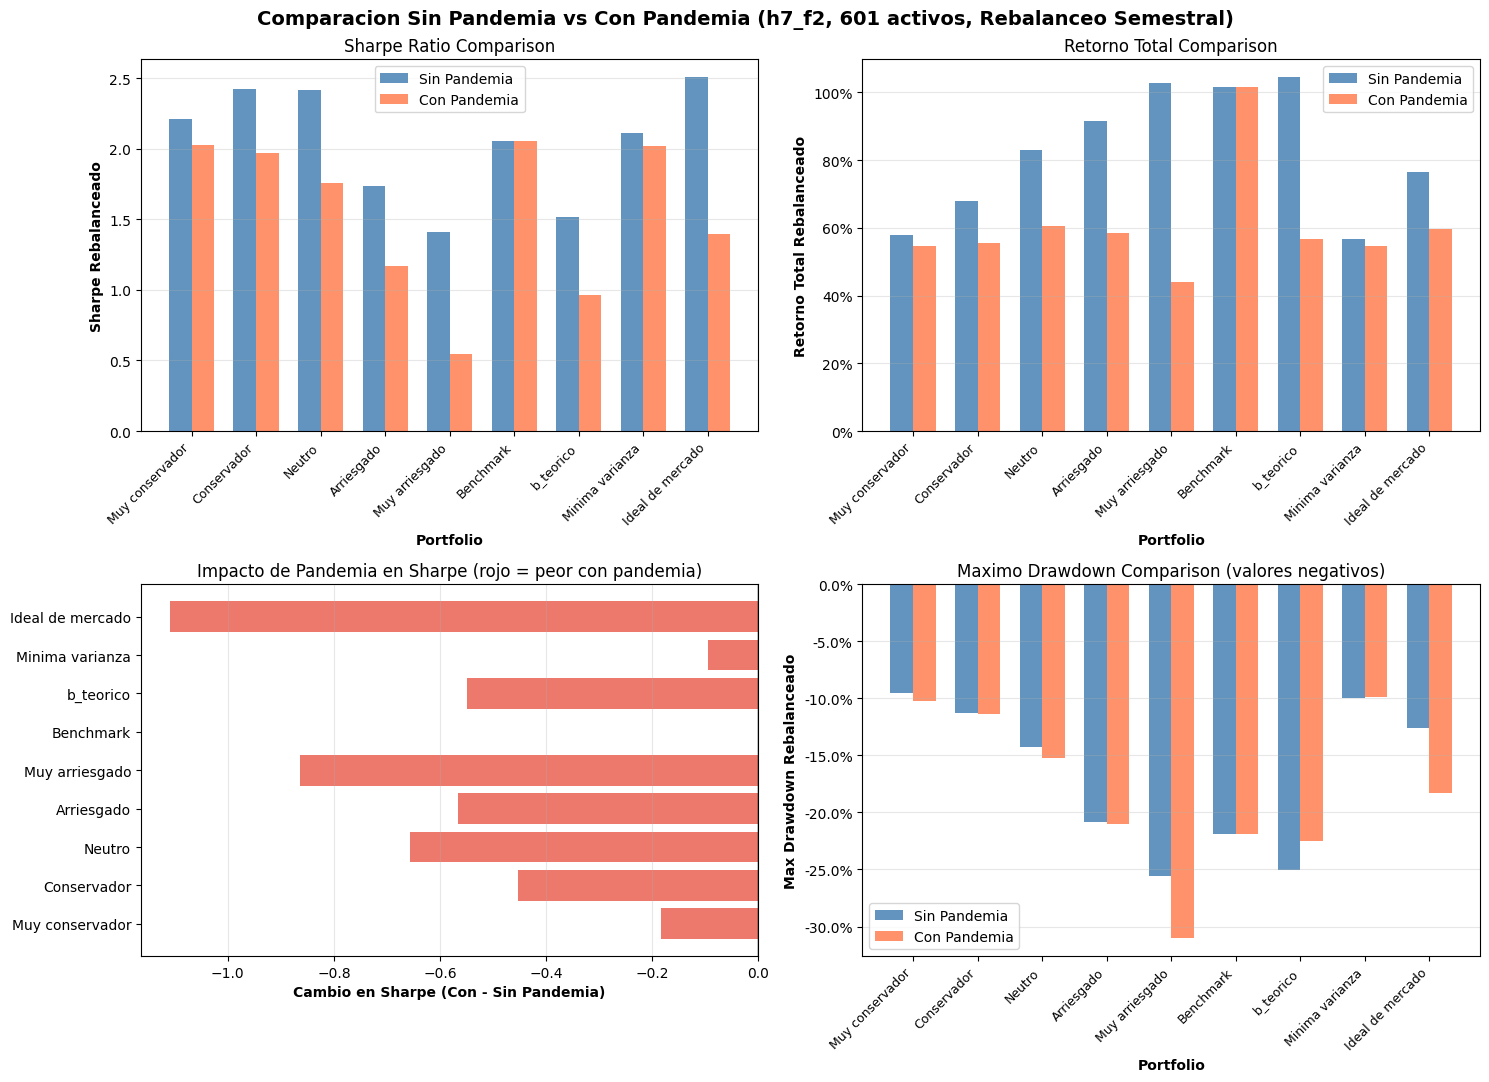

OK: ranking_sharpe_comparison.png


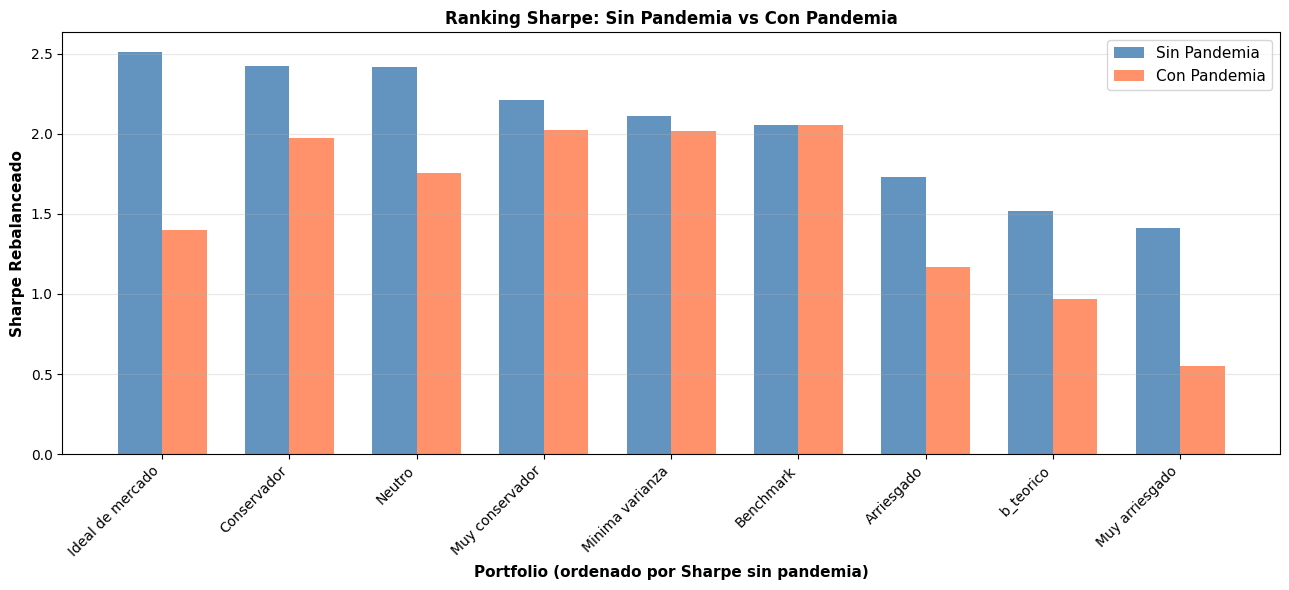

In [11]:
import matplotlib.pyplot as plt

output_label = f"h{HISTORICAL_YEARS}_f{FUTURE_YEARS}_{MARKET_SIZE}activos"
if 'comparison' not in globals():
    comparison_path = OUTPUT_DIR / f"comparison_sin_vs_con_pandemia_{output_label}.csv"
    if comparison_path.exists():
        comparison = pd.read_csv(comparison_path, index_col="portfolio")
        print(f"Datos cargados desde {comparison_path.name}")
    else:
        raise RuntimeError("Falta ejecutar BLOQUE 7 (Comparacion) y no existe CSV de comparacion.")

if comparison.empty:
    raise ValueError("comparison esta vacio; no se puede graficar.")

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Comparacion Sin Pandemia vs Con Pandemia (h7_f2, 601 activos, Rebalanceo Semestral)', fontsize=14, fontweight='bold')

portfolios = comparison.index.astype(str)
x = np.arange(len(portfolios))
width = 0.35

ax1 = axes[0, 0]
sharpe_sin = comparison['sharpe_rebalanceado_sin_pandemia'].values
sharpe_con = comparison['sharpe_rebalanceado_con_pandemia'].values
ax1.bar(x - width/2, sharpe_sin, width, label='Sin Pandemia', alpha=0.85, color='steelblue')
ax1.bar(x + width/2, sharpe_con, width, label='Con Pandemia', alpha=0.85, color='coral')
ax1.set_xlabel('Portfolio', fontweight='bold')
ax1.set_ylabel('Sharpe Rebalanceado', fontweight='bold')
ax1.set_title('Sharpe Ratio Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(portfolios, rotation=45, ha='right', fontsize=9)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

ax2 = axes[0, 1]
retorno_sin = comparison['retorno_total_rebalanceado_sin_pandemia'].values
retorno_con = comparison['retorno_total_rebalanceado_con_pandemia'].values
ax2.bar(x - width/2, retorno_sin, width, label='Sin Pandemia', alpha=0.85, color='steelblue')
ax2.bar(x + width/2, retorno_con, width, label='Con Pandemia', alpha=0.85, color='coral')
ax2.set_xlabel('Portfolio', fontweight='bold')
ax2.set_ylabel('Retorno Total Rebalanceado', fontweight='bold')
ax2.set_title('Retorno Total Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels(portfolios, rotation=45, ha='right', fontsize=9)
ax2.legend()
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax2.grid(True, alpha=0.3, axis='y')

ax3 = axes[1, 0]
delta_sharpe = comparison['delta_sharpe_rebalanceado_con_menos_sin'].values
colors = ['#e74c3c' if value < 0 else '#2ecc71' for value in delta_sharpe]
ax3.barh(portfolios, delta_sharpe, color=colors, alpha=0.75)
ax3.set_xlabel('Cambio en Sharpe (Con - Sin Pandemia)', fontweight='bold')
ax3.set_title('Impacto de Pandemia en Sharpe (rojo = peor con pandemia)')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax3.grid(True, alpha=0.3, axis='x')

ax4 = axes[1, 1]
drawdown_sin = comparison['max_drawdown_rebalanceado_sin_pandemia'].values
drawdown_con = comparison['max_drawdown_rebalanceado_con_pandemia'].values
ax4.bar(x - width/2, drawdown_sin, width, label='Sin Pandemia', alpha=0.85, color='steelblue')
ax4.bar(x + width/2, drawdown_con, width, label='Con Pandemia', alpha=0.85, color='coral')
ax4.set_xlabel('Portfolio', fontweight='bold')
ax4.set_ylabel('Max Drawdown Rebalanceado', fontweight='bold')
ax4.set_title('Maximo Drawdown Comparison (valores negativos)')
ax4.set_xticks(x)
ax4.set_xticklabels(portfolios, rotation=45, ha='right', fontsize=9)
ax4.legend()
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparison_sin_vs_con_pandemia.png', dpi=150, bbox_inches='tight')
print("OK: comparison_sin_vs_con_pandemia.png")
plt.show()

fig2, ax = plt.subplots(figsize=(13, 6))
sin_sorted = comparison['sharpe_rebalanceado_sin_pandemia'].sort_values(ascending=False)
con_aligned = comparison.loc[sin_sorted.index, 'sharpe_rebalanceado_con_pandemia']
x2 = np.arange(len(sin_sorted))
width2 = 0.35

ax.bar(x2 - width2/2, sin_sorted.values, width2, label='Sin Pandemia', alpha=0.85, color='steelblue')
ax.bar(x2 + width2/2, con_aligned.values, width2, label='Con Pandemia', alpha=0.85, color='coral')
ax.set_xlabel('Portfolio (ordenado por Sharpe sin pandemia)', fontweight='bold', fontsize=11)
ax.set_ylabel('Sharpe Rebalanceado', fontweight='bold', fontsize=11)
ax.set_title('Ranking Sharpe: Sin Pandemia vs Con Pandemia', fontsize=12, fontweight='bold')
ax.set_xticks(x2)
ax.set_xticklabels(sin_sorted.index, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ranking_sharpe_comparison.png', dpi=150, bbox_inches='tight')
print("OK: ranking_sharpe_comparison.png")
plt.show()


## Frontera Eficiente: Teorica vs Desempeno Real Futuro
La frontera eficiente muestra lo que el modelo espera con parametros estimados en entrenamiento, mientras que los puntos realizados muestran el comportamiento out-of-sample. La brecha entre ambos planos es evidencia de error de estimacion y posible overfitting, especialmente en portafolios agresivos o de tangencia.


sin_pandemia: 9 portafolios rebalanceados; 119 puntos de frontera
con_pandemia: 9 portafolios rebalanceados; 119 puntos de frontera


OK: frontera_portafolios_coloreados.png


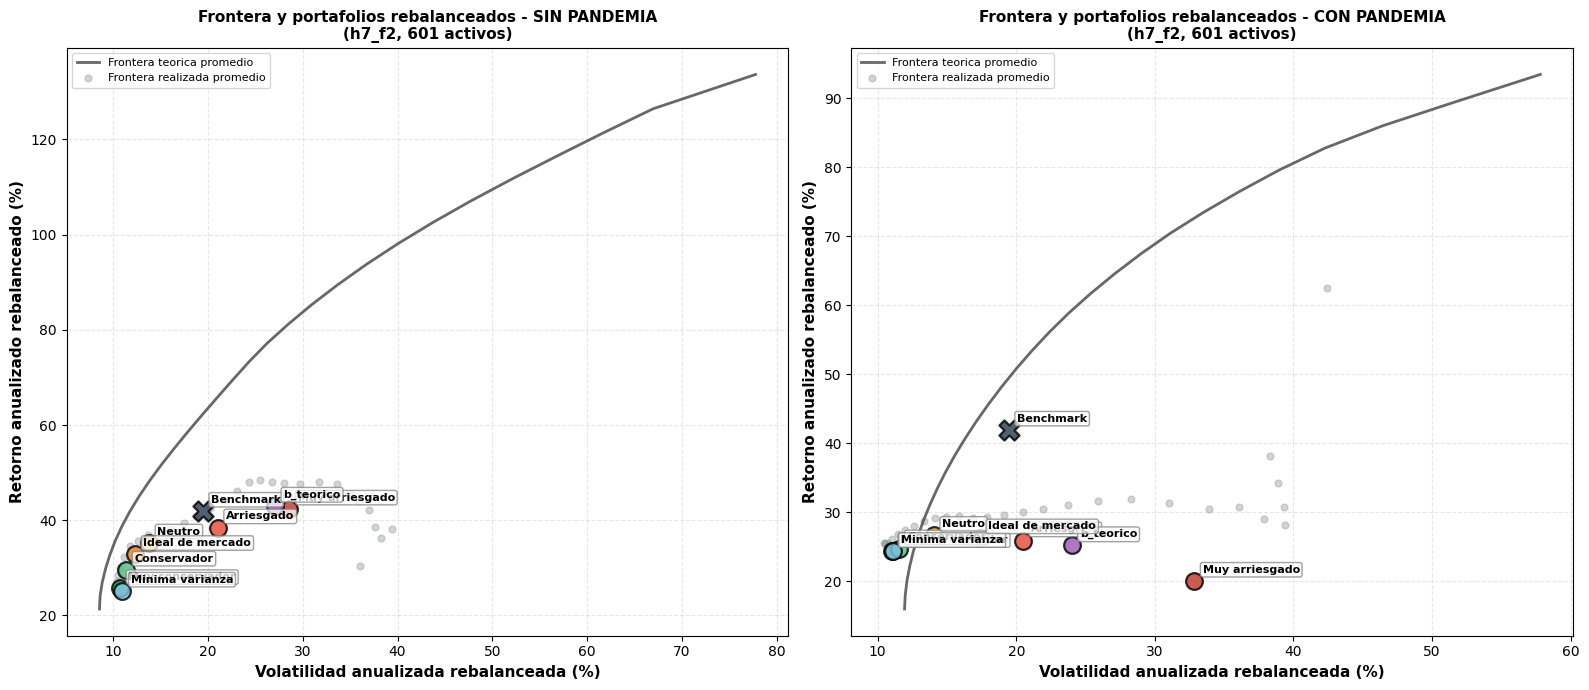

In [12]:
output_label = f"h{HISTORICAL_YEARS}_f{FUTURE_YEARS}_{MARKET_SIZE}activos"

color_map = {
    'Muy conservador': '#27ae60',
    'Conservador': '#52be80',
    'Minima varianza': '#85c1e2',
    'Neutro': '#f39c12',
    'Ideal de mercado': '#e67e22',
    'Arriesgado': '#e74c3c',
    'Muy arriesgado': '#c0392b',
    'b_teorico': '#9b59b6',
    'Tangencia': '#3498db',
    'Benchmark': '#2c3e50',
}

def get_rebalance_plot_data(scenario_key: str) -> pd.DataFrame:
    if 'all_results' in globals():
        df = all_results[scenario_key]['rebalance_df'].copy()
    else:
        path = OUTPUT_DIR / f"rebalance_summary_{output_label}.csv"
        if not path.exists():
            raise RuntimeError("Falta ejecutar BLOQUE 6 o generar rebalance_summary antes de graficar.")
        df = pd.read_csv(path)
        df = df[df['scenario'] == scenario_key].copy()
    if df.empty:
        raise ValueError(f"No hay datos rebalanceados para {scenario_key}")
    if 'retorno_anual_rebalanceado' not in df.columns:
        df['retorno_anual_rebalanceado'] = (1.0 + df['retorno_total_rebalanceado']) ** (1/FUTURE_YEARS) - 1
    if 'volatilidad_anual_rebalanceada' not in df.columns:
        df['volatilidad_anual_rebalanceada'] = df['volatilidad_diaria_rebalanceada'] * np.sqrt(TRADING_DAYS_PER_YEAR)
    return df

def get_frontier_plot_data(scenario_key: str) -> pd.DataFrame:
    if 'all_results' in globals():
        return all_results[scenario_key]['frontier_df'].copy()
    path = OUTPUT_DIR / f"frontier_segments_{output_label}.csv"
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    return df[df['scenario'] == scenario_key].copy() if 'scenario' in df.columns else df

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

for idx, scenario_key in enumerate(['sin_pandemia', 'con_pandemia']):
    ax = axes[idx]
    rebalance_df = get_rebalance_plot_data(scenario_key)
    frontier_df = get_frontier_plot_data(scenario_key)

    print(f"{scenario_key}: {len(rebalance_df)} portafolios rebalanceados; {len(frontier_df)} puntos de frontera")

    if not frontier_df.empty and {'frontier_point', 'volatilidad_anual_teorica', 'retorno_anual_teorico'}.issubset(frontier_df.columns):
        frontier_avg = frontier_df.groupby('frontier_point', as_index=False).mean(numeric_only=True)
        frontier_avg = frontier_avg.sort_values('volatilidad_anual_teorica')
        ax.plot(
            frontier_avg['volatilidad_anual_teorica'] * 100,
            frontier_avg['retorno_anual_teorico'] * 100,
            color='#4d4d4d', linewidth=2.0, alpha=0.85, label='Frontera teorica promedio',
        )
        if {'volatilidad_anual_real_futuro', 'retorno_anual_real_futuro'}.issubset(frontier_avg.columns):
            ax.scatter(
                frontier_avg['volatilidad_anual_real_futuro'] * 100,
                frontier_avg['retorno_anual_real_futuro'] * 100,
                s=24, color='#9aa0a6', alpha=0.45, label='Frontera realizada promedio',
            )

    for _, pdata in rebalance_df.iterrows():
        portfolio_name = str(pdata['portfolio'])
        vol_annual = pdata['volatilidad_anual_rebalanceada'] * 100
        ret_annual = pdata['retorno_anual_rebalanceado'] * 100
        color = color_map.get(portfolio_name, '#95a5a6')
        marker = 'X' if portfolio_name == 'Benchmark' else 'o'
        size = 210 if portfolio_name == 'Benchmark' else 145
        ax.scatter(vol_annual, ret_annual, s=size, alpha=0.82, color=color, marker=marker, edgecolors='black', linewidth=1.6, zorder=3)
        ax.annotate(
            portfolio_name,
            xy=(vol_annual, ret_annual),
            xytext=(6, 6),
            textcoords='offset points',
            fontsize=8,
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75, edgecolor='gray'),
            zorder=4,
        )

    scenario_label = 'SIN PANDEMIA' if scenario_key == 'sin_pandemia' else 'CON PANDEMIA'
    ax.set_xlabel('Volatilidad anualizada rebalanceada (%)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Retorno anualizado rebalanceado (%)', fontsize=11, fontweight='bold')
    ax.set_title(f'Frontera y portafolios rebalanceados - {scenario_label}\n(h{HISTORICAL_YEARS}_f{FUTURE_YEARS}, {MARKET_SIZE} activos)', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.legend(fontsize=8, loc='best')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'frontera_portafolios_coloreados.png', dpi=150, bbox_inches='tight')
print("OK: frontera_portafolios_coloreados.png")
plt.show()


## Diseno Experimental: Splits Aleatorios

Se incorpora el analisis de sensibilidad al horizonte de calibracion. El bloque usa las salidas ya generadas en `Implementacion multiples slipts/outputs_markowitz_cvxpy_splits_aleatorios` y reconstruye:

- ventana base de 9 anos;
- 28 combinaciones train/test con anos train + anos test <= 9;
- 70 ventanas aleatorias reproducibles con semilla fija;
- 560 evaluaciones de portafolios sobre 601 activos;
- 1.392 puntos de frontera eficiente;
- heatmap de Sharpe futuro promedio por split train/test.

Este analisis responde una pregunta distinta al caso pandemia: no pregunta si un split particular funciono, sino que tan sensible es el resultado al horizonte historico usado para calibrar mu y Sigma.



### Diseño experimental
- Ventana base de **9 años**.
- Cada combinación cumple **años train + años test <= 9**.
- **28 combinaciones** posibles, con test de **2 a 8 años**.
- **70 ventanas aleatorias** seleccionadas con semilla reproducible **42**.
- Cuando train + test = 9, solo hay una posición factible; si es menor, se usan hasta 3 inicios aleatorios.


,Experimento,Combinaciones,Ventanas,Evaluaciones,Activos,Frontera pts.
0,Splits aleatorios,28,70,560,601,1392


### Estructura por años de test

,Años test,Splits,Ventanas,Train mín-máx
0,2,7,19,1-7
1,3,6,16,1-6
2,4,5,13,1-5
3,5,4,10,1-4
4,6,3,7,1-3
5,7,2,4,1-2
6,8,1,1,1-1


### Benchmark global en splits aleatorios

...

- **Benchmark global**: Sharpe futuro promedio 2.057; mejor split por horizonte: h6_f2.

- **Horizonte de test**: El Benchmark pasa de Sharpe 2.32 con 2 años de test a 1.71 con 8 años.

- **Sensibilidad por perfil**: Mayor desviación de Sharpe: Muy arriesgado (0.46). Menor: Minima varianza (0.25).

- **Brecha teórico vs real**: Ideal de mercado: Sharpe teórico medio 5.01 vs Sharpe real 1.80.

Fuente: X:\Capstone final\Entrega 2\Implementación múltiples slipts\outputs_markowitz_cvxpy_splits_aleatorios
OK: heatmap_sharpe_train_test.csv
OK: heatmap_sharpe_train_test.png


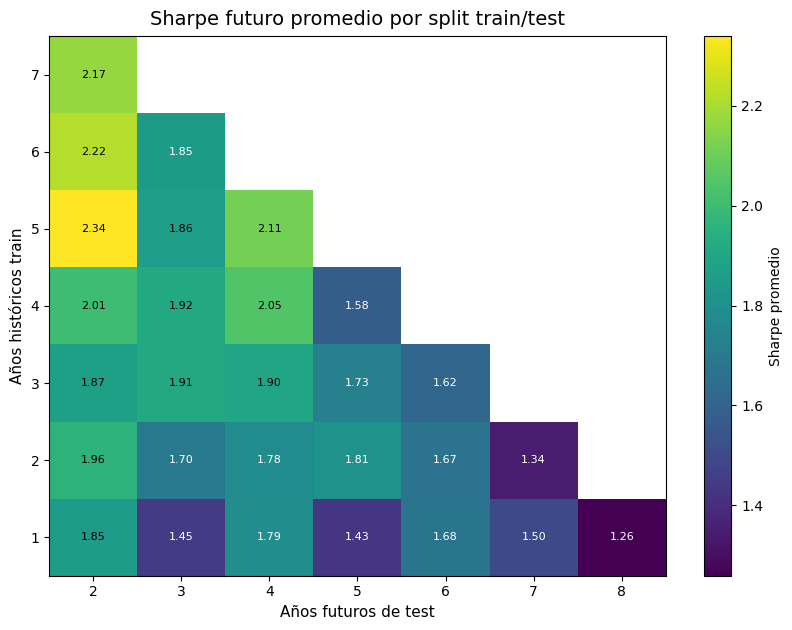

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

if "REPO_ROOT" not in globals():
    def find_project_root(start: Path) -> Path:
        start = start.resolve()
        for candidate in [start, *start.parents]:
            entrega_2 = candidate / "Entrega 2"
            if (entrega_2 / "Historical_Stocks_filtrado_sin_pandemia").exists():
                return candidate
            if candidate.name == "Entrega 2" and (candidate / "Historical_Stocks_filtrado_sin_pandemia").exists():
                return candidate.parent
        raise FileNotFoundError("No se pudo ubicar la raiz del proyecto 'Capstone final'. Ejecuta el notebook desde una carpeta dentro del proyecto.")
    REPO_ROOT = find_project_root(Path.cwd())
if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = REPO_ROOT / "Entrega 2" / "Implementaci\u00f3n caso benchmark te\u00f3rico" / "01_markowitz_vs_benchmark" / "outputs"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def find_multi_split_outputs(repo_root: Path) -> Path:
    preferred = repo_root / "Entrega 2" / "Implementación múltiples slipts" / "outputs_markowitz_cvxpy_splits_aleatorios"
    if preferred.exists():
        return preferred

    entrega_2 = repo_root / "Entrega 2"
    for candidate in entrega_2.iterdir():
        if candidate.is_dir() and "slipt" in candidate.name.lower():
            output_dir = candidate / "outputs_markowitz_cvxpy_splits_aleatorios"
            if output_dir.exists():
                return output_dir

    raise FileNotFoundError("No se encontró outputs_markowitz_cvxpy_splits_aleatorios.")


def format_float(value: float, decimals: int = 2) -> str:
    if pd.isna(value):
        return ""
    return f"{value:.{decimals}f}"


def format_pct(value: float, decimals: int = 1) -> str:
    if pd.isna(value):
        return ""
    return f"{value:.{decimals}%}"


MULTI_SPLIT_OUTPUT_DIR = find_multi_split_outputs(REPO_ROOT)
windows_path = MULTI_SPLIT_OUTPUT_DIR / "validation_windows.csv"
portfolios_path = MULTI_SPLIT_OUTPUT_DIR / "portfolios_summary_all_windows.csv"
frontier_path = MULTI_SPLIT_OUTPUT_DIR / "frontier_points_all_windows.csv"
robustness_path = MULTI_SPLIT_OUTPUT_DIR / "validation_robustness_summary.csv"
by_test_path = MULTI_SPLIT_OUTPUT_DIR / "validation_by_test_years_summary.csv"

required_paths = [windows_path, portfolios_path, frontier_path, robustness_path, by_test_path]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Faltan CSVs de splits aleatorios: " + ", ".join(path.name for path in missing_paths))

windows = pd.read_csv(windows_path, parse_dates=["historical_start", "historical_end", "future_start", "future_end"])
portfolios = pd.read_csv(portfolios_path, parse_dates=["historical_start", "historical_end", "future_start", "future_end"])
frontier = pd.read_csv(frontier_path)
robustness = pd.read_csv(robustness_path)
by_test = pd.read_csv(by_test_path)

for df in [windows, portfolios, frontier, robustness, by_test]:
    for col in df.columns:
        if col.endswith("years") or col in {"window_id", "n_assets", "n_windows", "n_experiments"}:
            df[col] = pd.to_numeric(df[col], errors="coerce")

for col in [
    "sharpe_real_futuro", "retorno_anual_real_futuro", "volatilidad_anual_real_futuro", "max_drawdown_futuro",
    "sharpe_teorico", "sharpe_futuro_mean", "retorno_futuro_mean", "volatilidad_futura_mean", "max_drawdown_futuro_mean",
]:
    for df in [portfolios, robustness, by_test]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

combinations = windows[["train_years", "test_years"]].drop_duplicates()
base_years = int((combinations["train_years"] + combinations["test_years"]).max())
random_seed = 42

experiment_summary = pd.DataFrame([
    {
        "Experimento": "Splits aleatorios",
        "Combinaciones": len(combinations),
        "Ventanas": len(windows),
        "Evaluaciones": len(portfolios),
        "Activos": int(windows["n_assets"].max()),
        "Frontera pts.": len(frontier),
    }
])

test_structure = (
    windows
    .groupby("test_years")
    .agg(
        Splits=("horizon", "nunique"),
        Ventanas=("split", "nunique"),
        Train_min=("train_years", "min"),
        Train_max=("train_years", "max"),
    )
    .reset_index()
    .sort_values("test_years")
)
test_structure["Años test"] = test_structure["test_years"].astype(int)
test_structure["Train mín-máx"] = test_structure.apply(
    lambda row: f"{int(row['Train_min'])}-{int(row['Train_max'])}", axis=1
)
test_structure_display = test_structure[["Años test", "Splits", "Ventanas", "Train mín-máx"]].copy()

heatmap_data = (
    portfolios
    .groupby(["train_years", "test_years"], as_index=False)["sharpe_real_futuro"]
    .mean()
    .pivot(index="train_years", columns="test_years", values="sharpe_real_futuro")
)
train_years = sorted(heatmap_data.index.dropna().astype(int), reverse=True)
test_years = sorted(heatmap_data.columns.dropna().astype(int))
heatmap_data = heatmap_data.reindex(index=train_years, columns=test_years)

matrix = heatmap_data.to_numpy(dtype=float)
masked_matrix = np.ma.masked_invalid(matrix)
fig, ax = plt.subplots(figsize=(8.4, 6.4))
cmap = plt.cm.viridis.copy()
cmap.set_bad(color="white")
vmin = float(np.nanmin(matrix))
vmax = float(np.nanmax(matrix))
im = ax.imshow(masked_matrix, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")

ax.set_title("Sharpe futuro promedio por split train/test", fontsize=14, pad=8)
ax.set_xlabel("Años futuros de test", fontsize=11)
ax.set_ylabel("Años históricos train", fontsize=11)
ax.set_xticks(np.arange(len(test_years)))
ax.set_yticks(np.arange(len(train_years)))
ax.set_xticklabels(test_years)
ax.set_yticklabels(train_years)

threshold = vmin + 0.55 * (vmax - vmin)
for i, train in enumerate(train_years):
    for j, test in enumerate(test_years):
        value = heatmap_data.loc[train, test]
        if pd.isna(value):
            continue
        text_color = "black" if value >= threshold else "white"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Sharpe promedio")
plt.tight_layout()

heatmap_csv = OUTPUT_DIR / "heatmap_sharpe_train_test.csv"
heatmap_png = OUTPUT_DIR / "heatmap_sharpe_train_test.png"
legacy_png = OUTPUT_DIR / "heatmap_sharpe_por_entrenamiento.png"
heatmap_data.to_csv(heatmap_csv, index_label="train_years")
plt.savefig(heatmap_png, dpi=150, bbox_inches="tight")
plt.savefig(legacy_png, dpi=150, bbox_inches="tight")

benchmark_all = portfolios[portfolios["portfolio"] == "Benchmark"].copy()
benchmark_by_horizon = robustness[robustness["portfolio"] == "Benchmark"].copy()
best_benchmark_horizon = benchmark_by_horizon.sort_values("sharpe_futuro_mean", ascending=False).iloc[0]
benchmark_summary = pd.DataFrame([
    {
        "Portafolio": "Benchmark",
        "Sharpe futuro": benchmark_all["sharpe_real_futuro"].mean(),
        "Mejor split": f"★ {best_benchmark_horizon['horizon']}",
        "Ret. futuro": benchmark_all["retorno_anual_real_futuro"].mean(),
        "Vol. futuro": benchmark_all["volatilidad_anual_real_futuro"].mean(),
        "Drawdown": benchmark_all["max_drawdown_futuro"].mean(),
    }
])
benchmark_display = benchmark_summary.copy()
benchmark_display["Sharpe futuro"] = benchmark_display["Sharpe futuro"].map(lambda x: format_float(x, 3))
for col in ["Ret. futuro", "Vol. futuro", "Drawdown"]:
    benchmark_display[col] = benchmark_display[col].map(lambda x: format_pct(x, 1))

best_train, best_test = heatmap_data.stack().idxmax()
best_heatmap_value = heatmap_data.stack().max()
benchmark_test = by_test[by_test["portfolio"] == "Benchmark"].set_index("test_years").sort_index()
benchmark_sharpe_2 = benchmark_test.loc[2, "sharpe_futuro_mean"] if 2 in benchmark_test.index else np.nan
benchmark_sharpe_8 = benchmark_test.loc[8, "sharpe_futuro_mean"] if 8 in benchmark_test.index else np.nan
portfolio_variability = portfolios.groupby("portfolio")["sharpe_real_futuro"].std().sort_values(ascending=False)
ideal = portfolios[portfolios["portfolio"] == "Ideal de mercado"]
ideal_theoretical = ideal["sharpe_teorico"].mean()
ideal_real = ideal["sharpe_real_futuro"].mean()

findings = pd.DataFrame([
    {"Hallazgo": "Mejor split promedio", "Resultado": f"h{int(best_train)}_f{int(best_test)} con Sharpe futuro promedio {best_heatmap_value:.2f}."},
    {"Hallazgo": "Benchmark global", "Resultado": f"Sharpe futuro promedio {benchmark_all['sharpe_real_futuro'].mean():.3f}; mejor split por horizonte: {best_benchmark_horizon['horizon']}."},
    {"Hallazgo": "Horizonte de test", "Resultado": f"El Benchmark pasa de Sharpe {benchmark_sharpe_2:.2f} con 2 años de test a {benchmark_sharpe_8:.2f} con 8 años."},
    {"Hallazgo": "Sensibilidad por perfil", "Resultado": f"Mayor desviación de Sharpe: {portfolio_variability.index[0]} ({portfolio_variability.iloc[0]:.2f}). Menor: {portfolio_variability.index[-1]} ({portfolio_variability.iloc[-1]:.2f})."},
    {"Hallazgo": "Brecha teórico vs real", "Resultado": f"Ideal de mercado: Sharpe teórico medio {ideal_theoretical:.2f} vs Sharpe real {ideal_real:.2f}."},
])

experiment_summary.to_csv(OUTPUT_DIR / "diseno_experimental_splits_aleatorios.csv", index=False)
test_structure_display.to_csv(OUTPUT_DIR / "estructura_anios_test_splits_aleatorios.csv", index=False)
benchmark_summary.to_csv(OUTPUT_DIR / "benchmark_splits_aleatorios_summary.csv", index=False)
findings.to_csv(OUTPUT_DIR / "hallazgos_splits_aleatorios.csv", index=False)

summary_markdown = f"""
### Diseño experimental
- Ventana base de **{base_years} años**.
- Cada combinación cumple **años train + años test <= {base_years}**.
- **{len(combinations)} combinaciones** posibles, con test de **{min(test_years)} a {max(test_years)} años**.
- **{len(windows)} ventanas aleatorias** seleccionadas con semilla reproducible **{random_seed}**.
- Cuando train + test = {base_years}, solo hay una posición factible; si es menor, se usan hasta 3 inicios aleatorios.
"""
display(Markdown(summary_markdown))
display(experiment_summary)

display(Markdown("### Estructura por años de test"))
display(test_structure_display)

display(Markdown("### Benchmark global en splits aleatorios"))
display(benchmark_display)

display(Markdown("### Hallazgos clave"))
for _, row in findings.iterrows():
    display(Markdown(f"- **{row['Hallazgo']}**: {row['Resultado']}"))

print(f"Fuente: {MULTI_SPLIT_OUTPUT_DIR}")
print(f"OK: {heatmap_csv.name}")
print(f"OK: {heatmap_png.name}")
plt.show()


## Validacion Robusta: Ventanas Moviles

Este bloque resume la validacion robusta original: 6 horizontes por 3 ventanas moviles, es decir, 18 evaluaciones fuera de muestra por portafolio. A diferencia de los splits aleatorios, aqui se compara una grilla mas acotada y ordenada de horizontes `h7_f2` a `h2_f7`, util para justificar el split principal usado en el analisis pandemia/rebalanceo.



### Resumen
No se usa un único split train/test. Se evalúan **6 horizontes x 3 ventanas = 18 ventanas fuera de muestra por portafolio** sobre **8 portafolios**.

**Hallazgo clave:** **7 años de historia + 2 de prueba** (`h7_f2`) ofrece el mayor Sharpe futuro medio agregado (**2.32**). En estos resultados, usar menos historia vuelve las estimaciones más inestables y deteriora el desempeño fuera de muestra.


,Horizonte,Años históricos,Años futuros,Sharpe futuro medio
0,h7_f2,7,2,2.32
1,h6_f3,6,3,2.07
2,h5_f4,5,4,1.88
3,h4_f5,4,5,1.66
4,h3_f6,3,6,1.60
5,h2_f7,2,7,1.35


Fuente: X:\Capstone final\Entrega 2\IMPLEMENTACIÓN OFICIAL\outputs_markowitz_cvxpy_variante_validacion
OK: validacion_robusta_sharpe_por_horizonte.png


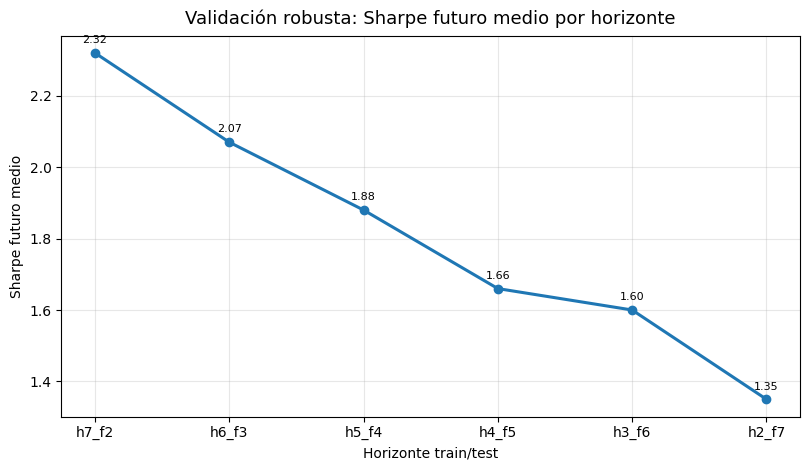

In [14]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

if "REPO_ROOT" not in globals():
    def find_project_root(start: Path) -> Path:
        start = start.resolve()
        for candidate in [start, *start.parents]:
            entrega_2 = candidate / "Entrega 2"
            if (entrega_2 / "Historical_Stocks_filtrado_sin_pandemia").exists():
                return candidate
            if candidate.name == "Entrega 2" and (candidate / "Historical_Stocks_filtrado_sin_pandemia").exists():
                return candidate.parent
        raise FileNotFoundError("No se pudo ubicar la raiz del proyecto 'Capstone final'. Ejecuta el notebook desde una carpeta dentro del proyecto.")
    REPO_ROOT = find_project_root(Path.cwd())
if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = REPO_ROOT / "Entrega 2" / "Implementaci\u00f3n caso benchmark te\u00f3rico" / "01_markowitz_vs_benchmark" / "outputs"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def find_robust_validation_outputs(repo_root: Path) -> Path:
    preferred = repo_root / "Entrega 2" / "IMPLEMENTACIÓN OFICIAL" / "outputs_markowitz_cvxpy_variante_validacion"
    if preferred.exists():
        return preferred

    entrega_2 = repo_root / "Entrega 2"
    for candidate in entrega_2.iterdir():
        if candidate.is_dir() and "OFICIAL" in candidate.name.upper():
            output_dir = candidate / "outputs_markowitz_cvxpy_variante_validacion"
            if output_dir.exists():
                return output_dir

    raise FileNotFoundError("No se encontró outputs_markowitz_cvxpy_variante_validacion.")


ROBUST_OUTPUT_DIR = find_robust_validation_outputs(REPO_ROOT)
robust_windows_path = ROBUST_OUTPUT_DIR / "validation_windows.csv"
robust_summary_path = ROBUST_OUTPUT_DIR / "validation_robustness_summary.csv"
robust_portfolios_path = ROBUST_OUTPUT_DIR / "portfolios_summary_all_windows.csv"

required_robust_paths = [robust_windows_path, robust_summary_path, robust_portfolios_path]
missing_robust_paths = [path for path in required_robust_paths if not path.exists()]
if missing_robust_paths:
    raise FileNotFoundError("Faltan CSVs de validación robusta: " + ", ".join(path.name for path in missing_robust_paths))

robust_windows = pd.read_csv(robust_windows_path)
robust_summary = pd.read_csv(robust_summary_path)
robust_portfolios = pd.read_csv(robust_portfolios_path)

for df in [robust_windows, robust_summary, robust_portfolios]:
    for col in df.columns:
        if col.endswith("years") or col in {"window_id", "n_windows"}:
            df[col] = pd.to_numeric(df[col], errors="coerce")
        if "sharpe" in col or "retorno" in col or "volatilidad" in col or "drawdown" in col:
            df[col] = pd.to_numeric(df[col], errors="coerce")

robust_horizon = (
    robust_summary
    .groupby("horizon", as_index=False)
    .agg(sharpe_futuro_medio=("sharpe_futuro_mean", "mean"))
)
robust_horizon[["Años históricos", "Años futuros"]] = robust_horizon["horizon"].str.extract(r"h(\d+)_f(\d+)").astype(int)
robust_horizon["order"] = robust_horizon["Años históricos"] * -10 + robust_horizon["Años futuros"]
robust_horizon = robust_horizon.sort_values(["Años futuros", "Años históricos"]).reset_index(drop=True)
robust_horizon_display = robust_horizon[["horizon", "Años históricos", "Años futuros", "sharpe_futuro_medio"]].copy()
robust_horizon_display = robust_horizon_display.rename(columns={
    "horizon": "Horizonte",
    "sharpe_futuro_medio": "Sharpe futuro medio",
})
robust_horizon_display["Sharpe futuro medio"] = robust_horizon_display["Sharpe futuro medio"].round(2)

best_row = robust_horizon.loc[robust_horizon["sharpe_futuro_medio"].idxmax()]
robust_windows_count = len(robust_windows)
robust_horizons_count = robust_windows["horizon"].nunique()
robust_windows_per_horizon = int(robust_windows.groupby("horizon")["window_id"].nunique().max())
robust_portfolios_count = robust_portfolios["portfolio"].nunique()

fig, ax = plt.subplots(figsize=(8.2, 4.8))
plot_df = robust_horizon_display.copy()
ax.plot(plot_df["Horizonte"], plot_df["Sharpe futuro medio"], marker="o", linewidth=2.2, color="#1f77b4")
ax.set_title("Validación robusta: Sharpe futuro medio por horizonte", fontsize=13, pad=8)
ax.set_xlabel("Horizonte train/test")
ax.set_ylabel("Sharpe futuro medio")
ax.grid(True, alpha=0.3)
for _, row in plot_df.iterrows():
    ax.annotate(f"{row['Sharpe futuro medio']:.2f}", (row["Horizonte"], row["Sharpe futuro medio"]), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
plt.tight_layout()
robust_plot = OUTPUT_DIR / "validacion_robusta_sharpe_por_horizonte.png"
plt.savefig(robust_plot, dpi=150, bbox_inches="tight")

robust_horizon_display.to_csv(OUTPUT_DIR / "validacion_robusta_ventanas_moviles.csv", index=False)

robust_markdown = f"""
### Resumen
No se usa un único split train/test. Se evalúan **{robust_horizons_count} horizontes x {robust_windows_per_horizon} ventanas = {robust_windows_count} ventanas fuera de muestra por portafolio** sobre **{robust_portfolios_count} portafolios**.

**Hallazgo clave:** **{best_row['Años históricos']:.0f} años de historia + {best_row['Años futuros']:.0f} de prueba** (`{best_row['horizon']}`) ofrece el mayor Sharpe futuro medio agregado (**{best_row['sharpe_futuro_medio']:.2f}**). En estos resultados, usar menos historia vuelve las estimaciones más inestables y deteriora el desempeño fuera de muestra.
"""
display(Markdown(robust_markdown))
display(robust_horizon_display)
print(f"Fuente: {ROBUST_OUTPUT_DIR}")
print(f"OK: {robust_plot.name}")
plt.show()


In [15]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

if "REPO_ROOT" not in globals():
    def find_project_root(start: Path) -> Path:
        start = start.resolve()
        for candidate in [start, *start.parents]:
            entrega_2 = candidate / "Entrega 2"
            if (entrega_2 / "Historical_Stocks_filtrado_sin_pandemia").exists():
                return candidate
            if candidate.name == "Entrega 2" and (candidate / "Historical_Stocks_filtrado_sin_pandemia").exists():
                return candidate.parent
        raise FileNotFoundError("No se pudo ubicar la raiz del proyecto 'Capstone final'. Ejecuta el notebook desde una carpeta dentro del proyecto.")
    REPO_ROOT = find_project_root(Path.cwd())
if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = REPO_ROOT / "Entrega 2" / "Implementaci\u00f3n caso benchmark te\u00f3rico" / "01_markowitz_vs_benchmark" / "outputs"

required_items = [
    ("Datos con pandemia", REPO_ROOT / "Historical_Stocks", None),
    ("Datos sin pandemia", REPO_ROOT / "Entrega 2" / "Historical_Stocks_filtrado_sin_pandemia" / "Historical_Stocks_sin_pandemia", None),
    ("Metadata F5", REPO_ROOT / "Entrega 2" / "Historical_Stocks_filtrado_sin_pandemia" / "tickers_filtrados_F5.csv", None),
    ("Resumen rebalanceado", OUTPUT_DIR / "rebalance_summary_h7_f2_601activos.csv", 18),
    ("Comparacion pandemia", OUTPUT_DIR / "comparison_sin_vs_con_pandemia_h7_f2_601activos.csv", 9),
    ("Heatmap splits", OUTPUT_DIR / "heatmap_sharpe_train_test.png", None),
    ("Diseno splits aleatorios", OUTPUT_DIR / "diseno_experimental_splits_aleatorios.csv", 1),
    ("Validacion robusta", OUTPUT_DIR / "validacion_robusta_ventanas_moviles.csv", 6),
]

multi_split_dir = REPO_ROOT / "Entrega 2" / "Implementaci\u00f3n m\u00faltiples slipts" / "outputs_markowitz_cvxpy_splits_aleatorios"
official_dir = REPO_ROOT / "Entrega 2" / "IMPLEMENTACI\u00d3N OFICIAL" / "outputs_markowitz_cvxpy_variante_validacion"
required_items.extend([
    ("Ventanas aleatorias", multi_split_dir / "validation_windows.csv", 70),
    ("Evaluaciones aleatorias", multi_split_dir / "portfolios_summary_all_windows.csv", 560),
    ("Frontera aleatoria", multi_split_dir / "frontier_points_all_windows.csv", 1392),
    ("Ventanas moviles oficiales", official_dir / "validation_windows.csv", 18),
])

rows = []
for label, path, expected_rows in required_items:
    exists = path.exists()
    observed_rows = None
    if exists and path.suffix.lower() == ".csv":
        observed_rows = len(pd.read_csv(path))
    ok = exists and (expected_rows is None or observed_rows == expected_rows)
    rows.append({
        "Item": label,
        "Existe": "OK" if exists else "FALTA",
        "Filas esperadas": expected_rows if expected_rows is not None else "",
        "Filas observadas": observed_rows if observed_rows is not None else "",
        "Estado": "OK" if ok else "REVISAR",
    })

validation_table = pd.DataFrame(rows)
display(Markdown("## Checklist Final de Validacion"))
display(validation_table)

if (validation_table["Estado"] != "OK").any():
    raise RuntimeError("La validacion final encontro items faltantes o conteos inesperados.")

print("Validacion final OK: estructura, outputs principales y conteos esperados estan disponibles.")


## Checklist Final de Validacion

,Item,Existe,Filas esperadas,Filas observadas,Estado
0,Datos con pandemia,OK,,,OK
1,Datos sin pandemia,OK,,,OK
2,Metadata F5,OK,,601,OK
3,Resumen rebalanceado,OK,18,18,OK
4,Comparacion pandemia,OK,9,9,OK
5,Heatmap splits,OK,,,OK
6,Diseno splits aleatorios,OK,1,1,OK
7,Validacion robusta,OK,6,6,OK
8,Ventanas aleatorias,OK,70,70,OK
9,Evaluaciones aleatorias,OK,560,560,OK


Validacion final OK: estructura, outputs principales y conteos esperados estan disponibles.


## Conclusiones Integradas del Diseno Experimental

### 1. Splits optimos
No hay un unico split optimo universal; depende del criterio usado:

- En el **heatmap de splits aleatorios**, el mejor promedio global es **h5_f2** con Sharpe futuro promedio **2.34**.
- Para el **Benchmark dentro de los splits aleatorios**, el mejor horizonte es **h6_f2** con Sharpe futuro medio **2.615**.
- En la **validacion robusta de ventanas moviles**, el mejor balance agregado es **h7_f2** con Sharpe futuro medio **2.32**.

Por trazabilidad academica, **h7_f2** queda justificado como split principal del analisis pandemia/rebalanceo: usa suficiente historia para estabilizar mu y Sigma y mantiene un periodo futuro corto donde la informacion sigue vigente. **h5_f2** y **h6_f2** deben reportarse como sensibilidad favorable, no como reemplazo automatico.

### 2. Con pandemia vs sin pandemia
El experimento mantiene fijo el futuro out-of-sample y cambia el regimen de entrenamiento. Incluir pandemia en entrenamiento deteriora especialmente los perfiles optimizados agresivos:

- Ideal de mercado cae **-1.108** puntos de Sharpe.
- Muy arriesgado cae **-0.863**.
- Neutro cae **-0.657**.
- Benchmark queda invariante porque no depende de reestimacion de mu ni Sigma.

La conclusion no es que la pandemia sea mala en si misma, sino que un regimen de estres altera las estimaciones y reduce la eficiencia fuera de muestra de carteras Markowitz mas sensibles al error de parametros.

### 3. Rebalanceo semestral
El rebalanceo semestral mejora algunos perfiles intermedios y defensivos, pero no domina siempre:

- Aporta en Conservador, Ideal de mercado, Minima varianza y Neutro.
- Perjudica a Muy arriesgado, Arriesgado, b_teorico y Benchmark frente a la version base sin rebalanceo.

Para la propuesta final, el rebalanceo debe presentarse como mecanismo de control y actualizacion, no como garantia de mayor Sharpe.

### 4. Benchmark vs Markowitz
El benchmark equiponderado top-20 es un competidor fuerte:

- En los 70 splits aleatorios, Benchmark tiene Sharpe futuro medio **2.057**, superior al promedio de los portafolios Markowitz optimizados.
- Minima varianza es el Markowitz mas robusto en promedio, con Sharpe futuro medio **1.940** y menor variabilidad que perfiles agresivos.
- Ideal de mercado exhibe overfitting: Sharpe teorico medio **5.01** frente a Sharpe real futuro **1.80**.

La recomendacion metodologica es reportar siempre Benchmark y Minima varianza como lineas base. Los portafolios Markowitz pueden superar al benchmark en splits puntuales, pero requieren validacion robusta para evitar conclusiones inducidas por un periodo favorable.

### 5. Respuesta final del diseno
El diseno experimental muestra que la seleccion del horizonte de calibracion, la inclusion de episodios de estres y la politica de rebalanceo cambian materialmente el resultado. Para una entrega defendible:

- usar **h7_f2** como caso central;
- reportar **h5_f2** como mejor celda promedio del heatmap;
- destacar **h6_f2** como mejor caso del Benchmark en splits aleatorios;
- separar claramente resultados con y sin pandemia;
- interpretar el rebalanceo como trade-off;
- comparar cualquier Markowitz contra Benchmark y Minima varianza antes de afirmar superioridad.
